# 📊 Portafolio de Mínima Varianza
### Análisis con dos períodos: Enero 2025 vs 12 de Febrero 2025

Este notebook descarga datos de acciones desde Yahoo Finance, optimiza un portafolio de mínima varianza usando la frontera eficiente de Markowitz, y visualiza el desempeño en ambos períodos.

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('darkgrid')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
# ============================================================
# 2. CONFIGURACIÓN: ACCIONES Y PERÍODOS
# ============================================================

TICKERS = ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL','META', 'TSLA', 'WMT', 'BRK-B', 'JPM', 'LLY', 'V', 'JNJ', 'MU', 'ORCL', 'AMD', 'COST', 'MA', 'NFLX', 'COST', 'CAT', 'BAC', 'ABBV', 'CSCO', 'INTC', 'PLTR', 'PG', 'HD', 'KO', 'AMAT', 'GEV', 'GE', 'MRK', 'TXN']

PERIODOS = {
    'Corrida 1 — Desde Enero 2026': {
        'start':     '2026-01-02',
        'end':       '2026-04-22',
        'color':     '#2E86AB',
        'rf_series': 'DTB3'          # tasa 3 meses
    },
    'Corrida 2 — Desde 12 Feb 2026': {
        'start':     '2026-02-12',
        'end':       '2026-04-22',
        'color':     '#E84855',
        'rf_series': 'DTB3'          # tasa 3 meses
    },
    'Corrida 3 — Desde Enero 2025': {
        'start':     '2025-01-02',
        'end':       '2026-04-22',
        'color':     '#27AE60',
        'rf_series': 'DGS1'          # tasa 1 año
    }
}

print(f'📋 Acciones seleccionadas: {TICKERS}')
print(f'📅 Períodos configurados: {list(PERIODOS.keys())}')

📋 Acciones seleccionadas: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'WMT', 'BRK-B', 'JPM', 'LLY', 'V', 'JNJ', 'MU', 'ORCL', 'AMD', 'COST', 'MA', 'NFLX', 'COST', 'CAT', 'BAC', 'ABBV', 'CSCO', 'INTC', 'PLTR', 'PG', 'HD', 'KO', 'AMAT', 'GEV', 'GE', 'MRK', 'TXN']
📅 Períodos configurados: ['Corrida 1 — Desde Enero 2026', 'Corrida 2 — Desde 12 Feb 2026', 'Corrida 3 — Desde Enero 2025']


In [3]:
# ============================================================
# 3. DESCARGA DE DATOS DESDE YAHOO FINANCE
# ============================================================

def descargar_precios(tickers, start, end):
    """Descarga precios ajustados de cierre desde yfinance."""
    print(f'  Descargando datos del {start} al {end}...')
    datos = yf.download(tickers, start=start, end=end,
                        auto_adjust=True, progress=False)
    precios = datos['Close']
    # Eliminar columnas con demasiados NaN
    precios = precios.dropna(axis=1, thresh=int(len(precios)*0.9))
    precios = precios.ffill().dropna()
    print(f'  ✅ {precios.shape[0]} días | {precios.shape[1]} acciones válidas')
    return precios

datos_periodos = {}
for nombre, cfg in PERIODOS.items():
    print(f'\n🔽 {nombre}')
    datos_periodos[nombre] = descargar_precios(TICKERS, cfg['start'], cfg['end'])


🔽 Corrida 1 — Desde Enero 2026
  Descargando datos del 2026-01-02 al 2026-04-22...
  ✅ 75 días | 33 acciones válidas

🔽 Corrida 2 — Desde 12 Feb 2026
  Descargando datos del 2026-02-12 al 2026-04-22...
  ✅ 47 días | 33 acciones válidas

🔽 Corrida 3 — Desde Enero 2025
  Descargando datos del 2025-01-02 al 2026-04-22...
  ✅ 325 días | 33 acciones válidas


In [4]:
# ============================================================
# 3.5. TASAS LIBRES DE RIESGO & MÉTRICAS POR ACCIÓN
# ============================================================

import os

# --- Tasas libres de riesgo desde archivos locales ---
_dir = os.path.dirname(os.path.abspath('portafolio_minima_varianza.ipynb'))

def leer_tasa(archivo, columna, start, end):
    """Lee un CSV de FRED y devuelve la tasa promedio del período en decimal."""
    df = pd.read_csv(archivo, parse_dates=['observation_date'], index_col='observation_date')
    df = df.replace('.', float('nan')).astype(float)
    mascara = (df.index >= start) & (df.index <= end)
    promedio = df.loc[mascara, columna].dropna().mean()
    return promedio / 100   # % → decimal

dtb3_file = os.path.join(_dir, 'DTB3.csv')
dgs1_file = os.path.join(_dir, 'DGS1.csv')

# Calcular una tasa por período usando su ventana de tiempo
RF_RATES = {}
for nombre, cfg in PERIODOS.items():
    serie = cfg['rf_series']
    archivo = dtb3_file if serie == 'DTB3' else dgs1_file
    tasa = leer_tasa(archivo, serie, cfg['start'], cfg['end'])
    RF_RATES[serie] = tasa   # se sobreescribe si hay duplicados, pero es el mismo período
    print(f'  {nombre}: {serie} = {tasa*100:.3f}%')

# Recalcular por separado para tener ambas tasas disponibles
RF_RATES['DTB3'] = leer_tasa(dtb3_file, 'DTB3', '2026-01-02', '2026-04-22')
RF_RATES['DGS1'] = leer_tasa(dgs1_file, 'DGS1', '2025-01-02', '2026-04-22')
print(f'\n📈 DTB3 (3 meses, 2026):      {RF_RATES["DTB3"]*100:.3f}%')
print(f'📈 DGS1 (1 año,  2025-2026):  {RF_RATES["DGS1"]*100:.3f}%')

# --- Métricas por acción ---
def metricas_accion(precios):
    """Devuelve std anual, max drawdown y mayor subida diaria por ticker."""
    ret  = np.log(precios / precios.shift(1)).dropna()
    rows = []
    for ticker in precios.columns:
        p = precios[ticker]
        r = ret[ticker]
        std_anual    = r.std() * np.sqrt(252) * 100
        rolling_max  = p.cummax()
        max_dd       = ((p - rolling_max) / rolling_max * 100).min()
        mayor_subida = r.max() * 100
        rows.append({
            'Ticker':                   ticker,
            'Desv. Est. Anual (%)':     round(std_anual,    2),
            'Max Drawdown (%)':         round(max_dd,        2),
            'Mayor Subida Diaria (%)':  round(mayor_subida,  2)
        })
    return (pd.DataFrame(rows)
              .set_index('Ticker')
              .sort_values('Desv. Est. Anual (%)', ascending=False))

print('\n📊 MÉTRICAS POR ACCIÓN')
for nombre, precios in datos_periodos.items():
    print(f'\n{"─"*62}')
    print(f'  {nombre}')
    print(f'{"─"*62}')
    print(metricas_accion(precios).to_string())

  Corrida 1 — Desde Enero 2026: DTB3 = 3.598%
  Corrida 2 — Desde 12 Feb 2026: DTB3 = 3.611%
  Corrida 3 — Desde Enero 2025: DGS1 = 3.835%

📈 DTB3 (3 meses, 2026):      3.598%
📈 DGS1 (1 año,  2025-2026):  3.835%

📊 MÉTRICAS POR ACCIÓN

──────────────────────────────────────────────────────────────
  Corrida 1 — Desde Enero 2026
──────────────────────────────────────────────────────────────
        Desv. Est. Anual (%)  Max Drawdown (%)  Mayor Subida Diaria (%)
Ticker                                                                 
INTC                   77.41            -24.17                    11.08
MU                     69.92            -30.28                     9.55
AMD                    63.60            -26.47                     8.41
ORCL                   56.08            -33.32                    11.95
PLTR                   54.80            -29.51                     6.62
AMAT                   53.66            -18.19                     8.49
GEV                    42.79   

In [5]:
# ============================================================
# 4. OPTIMIZACIÓN DE MÍNIMA VARIANZA
# ============================================================

def calcular_retornos(precios):
    """Retornos logarítmicos diarios."""
    return np.log(precios / precios.shift(1)).dropna()

def portfolio_varianza(pesos, cov_matrix):
    return pesos @ cov_matrix @ pesos

def portfolio_retorno(pesos, retornos_medios):
    return pesos @ retornos_medios

def optimizar_minima_varianza(retornos, rf_rate=0.0):
    """Encuentra el portafolio de mínima varianza global."""
    n = retornos.shape[1]
    media = retornos.mean() * 252
    cov   = retornos.cov()  * 252

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0.0, 1.0)] * n
    w0          = np.ones(n) / n

    res = minimize(
        portfolio_varianza,
        w0,
        args=(cov.values,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )

    pesos_opt  = res.x
    var_opt    = portfolio_varianza(pesos_opt, cov.values)
    vol_opt    = np.sqrt(var_opt)
    ret_opt    = portfolio_retorno(pesos_opt, media.values)
    # Fórmula correcta: (retorno - tasa libre de riesgo) / volatilidad
    sharpe_opt = (ret_opt - rf_rate) / vol_opt if vol_opt > 0 else 0

    return {
        'pesos':       pd.Series(pesos_opt, index=retornos.columns),
        'retorno':     ret_opt,
        'volatilidad': vol_opt,
        'sharpe':      sharpe_opt,
        'rf_rate':     rf_rate,
        'media':       media,
        'cov':         cov
    }

resultados = {}
for nombre, cfg in PERIODOS.items():
    print(f'\n⚙️  Optimizando: {nombre}')
    rf_rate = RF_RATES.get(cfg['rf_series'], 0.0)
    ret_log = calcular_retornos(datos_periodos[nombre])
    res     = optimizar_minima_varianza(ret_log, rf_rate=rf_rate)
    resultados[nombre] = {'precios': datos_periodos[nombre], 'retornos': ret_log, **res}

    print(f'   Tasa libre de riesgo   : {rf_rate*100:.3f}% ({cfg["rf_series"]})')
    print(f'   Retorno anual esperado : {res["retorno"]*100:.2f}%')
    print(f'   Volatilidad anual      : {res["volatilidad"]*100:.2f}%')
    print(f'   Sharpe ratio           : {res["sharpe"]:.3f}')
    print(f'   Acciones con peso > 1% : {(res["pesos"]>0.01).sum()}')


⚙️  Optimizando: Corrida 1 — Desde Enero 2026
   Tasa libre de riesgo   : 3.598% (DTB3)
   Retorno anual esperado : 8.98%
   Volatilidad anual      : 8.49%
   Sharpe ratio           : 0.634
   Acciones con peso > 1% : 11

⚙️  Optimizando: Corrida 2 — Desde 12 Feb 2026
   Tasa libre de riesgo   : 3.598% (DTB3)
   Retorno anual esperado : -11.32%
   Volatilidad anual      : 8.57%
   Sharpe ratio           : -1.740
   Acciones con peso > 1% : 9

⚙️  Optimizando: Corrida 3 — Desde Enero 2025
   Tasa libre de riesgo   : 3.835% (DGS1)
   Retorno anual esperado : 18.75%
   Volatilidad anual      : 11.00%
   Sharpe ratio           : 1.355
   Acciones con peso > 1% : 11


In [6]:
# ============================================================
# FUNCIONES AUXILIARES — Frontera & SP500
# ============================================================

def simular_portafolios(media, cov, n_sim=6000):
    n = len(media)
    rets, vols = [], []
    for _ in range(n_sim):
        w = np.random.dirichlet(np.ones(n))
        r = w @ media.values
        v = np.sqrt(w @ cov.values @ w)
        rets.append(r); vols.append(v)
    return np.array(rets), np.array(vols)

def calcular_frontera(media, cov, n_puntos=120):
    """Curva de mínima varianza para cada nivel de retorno."""
    n = len(media)
    rets_fe, vols_fe = [], []
    targets = np.linspace(media.min() * 0.85, media.max() * 1.10, n_puntos)
    for target in targets:
        try:
            r = minimize(
                lambda w: w @ cov.values @ w, np.ones(n) / n,
                method='SLSQP', bounds=[(0, 1)] * n,
                constraints=[
                    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                    {'type': 'eq', 'fun': lambda w, t=target: w @ media.values - t}
                ],
                options={'ftol': 1e-10, 'maxiter': 400}
            )
            if r.success:
                vols_fe.append(np.sqrt(r.fun))
                rets_fe.append(target)
        except Exception:
            pass
    return np.array(vols_fe), np.array(rets_fe)

def get_sp500(start, end):
    raw = yf.download('^GSPC', start=start, end=end,
                      auto_adjust=True, progress=False)['Close'].squeeze()
    ret = np.log(raw / raw.shift(1)).dropna()
    val = 100 * np.exp(ret.cumsum())
    return val

print('✅ Funciones auxiliares cargadas')


✅ Funciones auxiliares cargadas


---
## 📈 SECCIÓN A — Portafolio de Mínima Varianza (universo completo)


In [7]:
# ============================================================
# A1. FRONTERA EFICIENTE — Monte Carlo + CML + Curva
# ============================================================
fig, axes = plt.subplots(1, len(nombres), figsize=(7 * len(nombres), 7))
if len(nombres) == 1: axes = [axes]
fig.suptitle('Frontera Eficiente — Monte Carlo + CML', fontsize=13, fontweight='bold')

for ax, (nombre, res), color in zip(axes, resultados.items(), colores):
    rets, vols = simular_portafolios(res['media'], res['cov'])
    rf         = res['rf_rate']
    sharpes    = (rets - rf) / vols

    # Nube Monte Carlo
    sc = ax.scatter(vols * 100, rets * 100, c=sharpes, cmap='viridis',
                    alpha=0.3, s=8, zorder=1)
    plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

    # Curva completa de mínima varianza (línea circular / frontera)
    vfe, rfe = calcular_frontera(res['media'], res['cov'])
    if len(vfe) > 3:
        ax.plot(vfe * 100, rfe * 100, 'w-',  linewidth=4.0, zorder=3, alpha=0.6)
        ax.plot(vfe * 100, rfe * 100, 'k--', linewidth=1.8, zorder=4,
                label='Frontera mín. varianza', alpha=0.9)
        # Parte eficiente (≥ retorno del MVP) resaltada
        mask = rfe >= res['retorno']
        if mask.any():
            ax.plot(vfe[mask] * 100, rfe[mask] * 100, color=color,
                    linewidth=2.5, zorder=5, alpha=0.85, label='Frontera eficiente')

    # MVP
    ax.scatter(res['volatilidad'] * 100, res['retorno'] * 100,
               color=color, s=230, zorder=7, marker='*',
               edgecolors='black', linewidths=0.8,
               label=f'MVP  σ={res["volatilidad"]*100:.1f}%  μ={res["retorno"]*100:.1f}%')

    # Tangencia (máx Sharpe simulado)
    idx_tan         = np.argmax(sharpes)
    vol_tan         = vols[idx_tan] * 100
    ret_tan         = rets[idx_tan] * 100
    sharpe_tan      = sharpes[idx_tan]
    ax.scatter(vol_tan, ret_tan, color='gold', s=180, zorder=7, marker='^',
               edgecolors='black', linewidths=0.8,
               label=f'Tangencia  SR={sharpe_tan:.2f}')

    # CML
    vol_cml = np.linspace(0, vols.max() * 100 * 1.25, 300)
    ret_cml = rf * 100 + sharpe_tan * vol_cml
    ax.plot(vol_cml, ret_cml, color='#FF6B35', linewidth=1.8, zorder=6,
            label=f'CML  pendiente={sharpe_tan:.2f}')
    ax.scatter(0, rf * 100, color='#FF6B35', s=100, zorder=8, marker='D',
               edgecolors='black', linewidths=0.8, label=f'RF = {rf*100:.2f}%')

    ax.set_xlabel('Volatilidad Anual (%)')
    ax.set_ylabel('Retorno Anual Esperado (%)')
    ax.set_title(nombre, fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


NameError: name 'nombres' is not defined

In [ ]:
# ============================================================
# 5. TABLA DE PESOS ÓPTIMOS
# ============================================================

nombres    = list(resultados.keys())
etiquetas  = [n.split('—')[1].strip() if '—' in n else n for n in nombres]
colores_map = {n: PERIODOS[n]['color'] for n in nombres}

df_pesos = pd.DataFrame(
    {lbl: resultados[n]['pesos'] for lbl, n in zip(etiquetas, nombres)}
) * 100
df_pesos = df_pesos.sort_values(etiquetas[0], ascending=False)
df_pesos.columns.name = 'Período'

print('\n📌 PESOS ÓPTIMOS DEL PORTAFOLIO DE MÍNIMA VARIANZA (%)')
print('='*65)
print(df_pesos.round(2).to_string())

print('\n📊 MÉTRICAS DE DESEMPEÑO')
print('='*65)
metricas_df = pd.DataFrame([
    {
        'Período':            lbl,
        'Retorno Anual (%)':  f"{resultados[n]['retorno']*100:.2f}",
        'Volatilidad (%)':    f"{resultados[n]['volatilidad']*100:.2f}",
        'RF Rate (%)':        f"{resultados[n]['rf_rate']*100:.3f}",
        'Sharpe Ratio':       f"{resultados[n]['sharpe']:.3f}"
    }
    for lbl, n in zip(etiquetas, nombres)
]).set_index('Período')
print(metricas_df.to_string())


📌 PESOS ÓPTIMOS DEL PORTAFOLIO DE MÍNIMA VARIANZA (%)
Período  Desde Enero 2026  Desde 12 Feb 2026  Desde Enero 2025
Ticker                                                        
BRK-B               25.61              24.53             10.93
JNJ                 24.64              27.22             23.14
KO                  17.64              15.50             27.00
COST                 8.37               9.97              5.79
MSFT                 6.64               6.17             14.30
BAC                  4.57               5.13              2.15
NVDA                 3.06               1.03              1.02
MA                   2.33               0.00              0.00
PLTR                 2.23               3.95              0.00
CSCO                 2.21               6.12              3.30
ORCL                 1.98               0.37              1.61
NFLX                 0.72               0.00              0.51
PG                   0.00               0.00              4.25


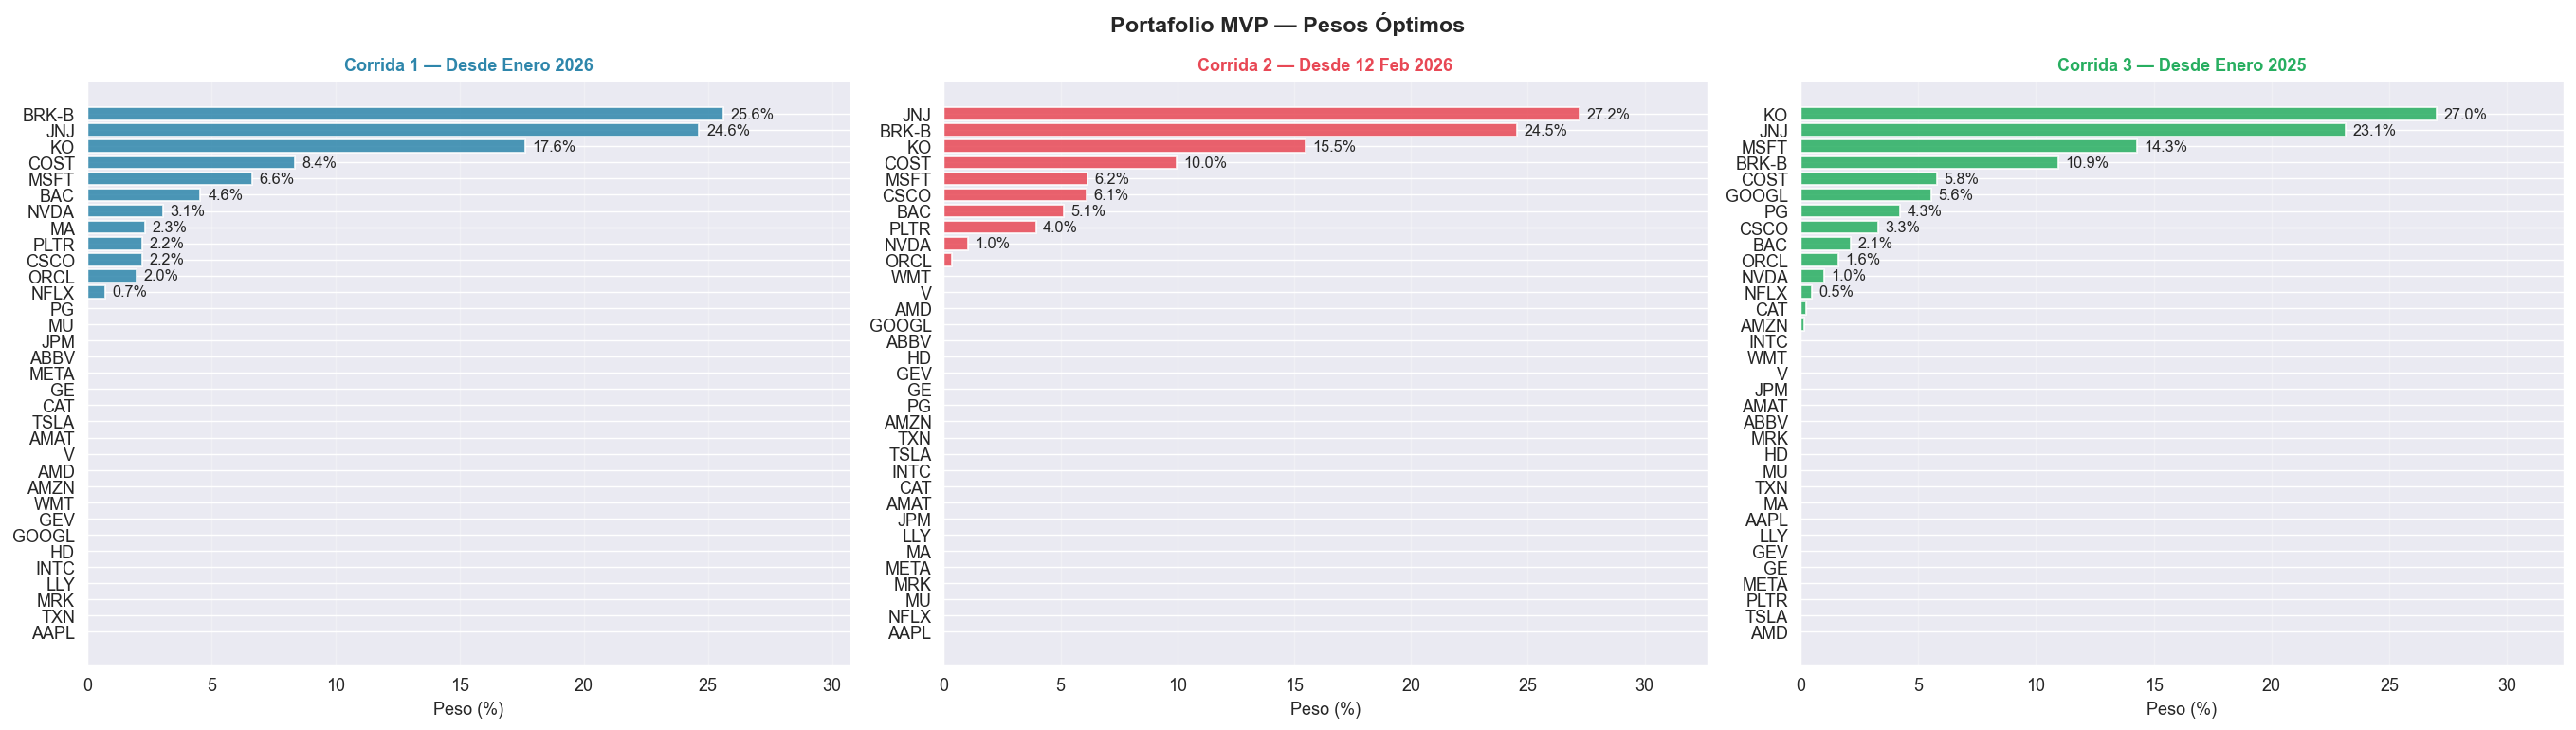


📊 MÉTRICAS DEL PORTAFOLIO MVP
                  Retorno Anual (%) Volatilidad (%) Sharpe Ratio
Período                                                         
Desde Enero 2026               8.98            8.49        0.634
Desde 12 Feb 2026            -11.32            8.57       -1.740
Desde Enero 2025              18.75           11.00        1.355


In [ ]:
# ============================================================
# A3. PESOS ÓPTIMOS + MÉTRICAS (tabla)
# ============================================================
fig, axes = plt.subplots(1, len(nombres), figsize=(7 * len(nombres), 6))
if len(nombres) == 1: axes = [axes]
fig.suptitle('Portafolio MVP — Pesos Óptimos', fontsize=13, fontweight='bold')

for col, (nombre, color) in enumerate(zip(nombres, colores)):
    res   = resultados[nombre]
    ax_w  = axes[col]
    pesos = res['pesos'].sort_values(ascending=True)
    bars  = ax_w.barh(pesos.index, pesos.values * 100, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, pesos.values):
        if val > 0.005:
            ax_w.text(val * 100 + 0.3, bar.get_y() + bar.get_height() / 2,
                      f'{val*100:.1f}%', va='center', fontsize=9)
    ax_w.set_xlabel('Peso (%)')
    ax_w.set_title(nombre, fontsize=10, color=color, fontweight='bold')
    ax_w.set_xlim(0, pesos.values.max() * 120)
    ax_w.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ── Tabla de métricas ──────────────────────────────────────────────
print('\n📊 MÉTRICAS DEL PORTAFOLIO MVP')
print('=' * 65)
met_df = pd.DataFrame([
    {
        'Período':           lbl,
        'Retorno Anual (%)': f"{resultados[n]['retorno']*100:.2f}",
        'Volatilidad (%)':   f"{resultados[n]['volatilidad']*100:.2f}",
        'Sharpe Ratio':      f"{resultados[n]['sharpe']:.3f}"
    }
    for lbl, n in zip(etiquetas, nombres)
]).set_index('Período')
print(met_df.to_string())


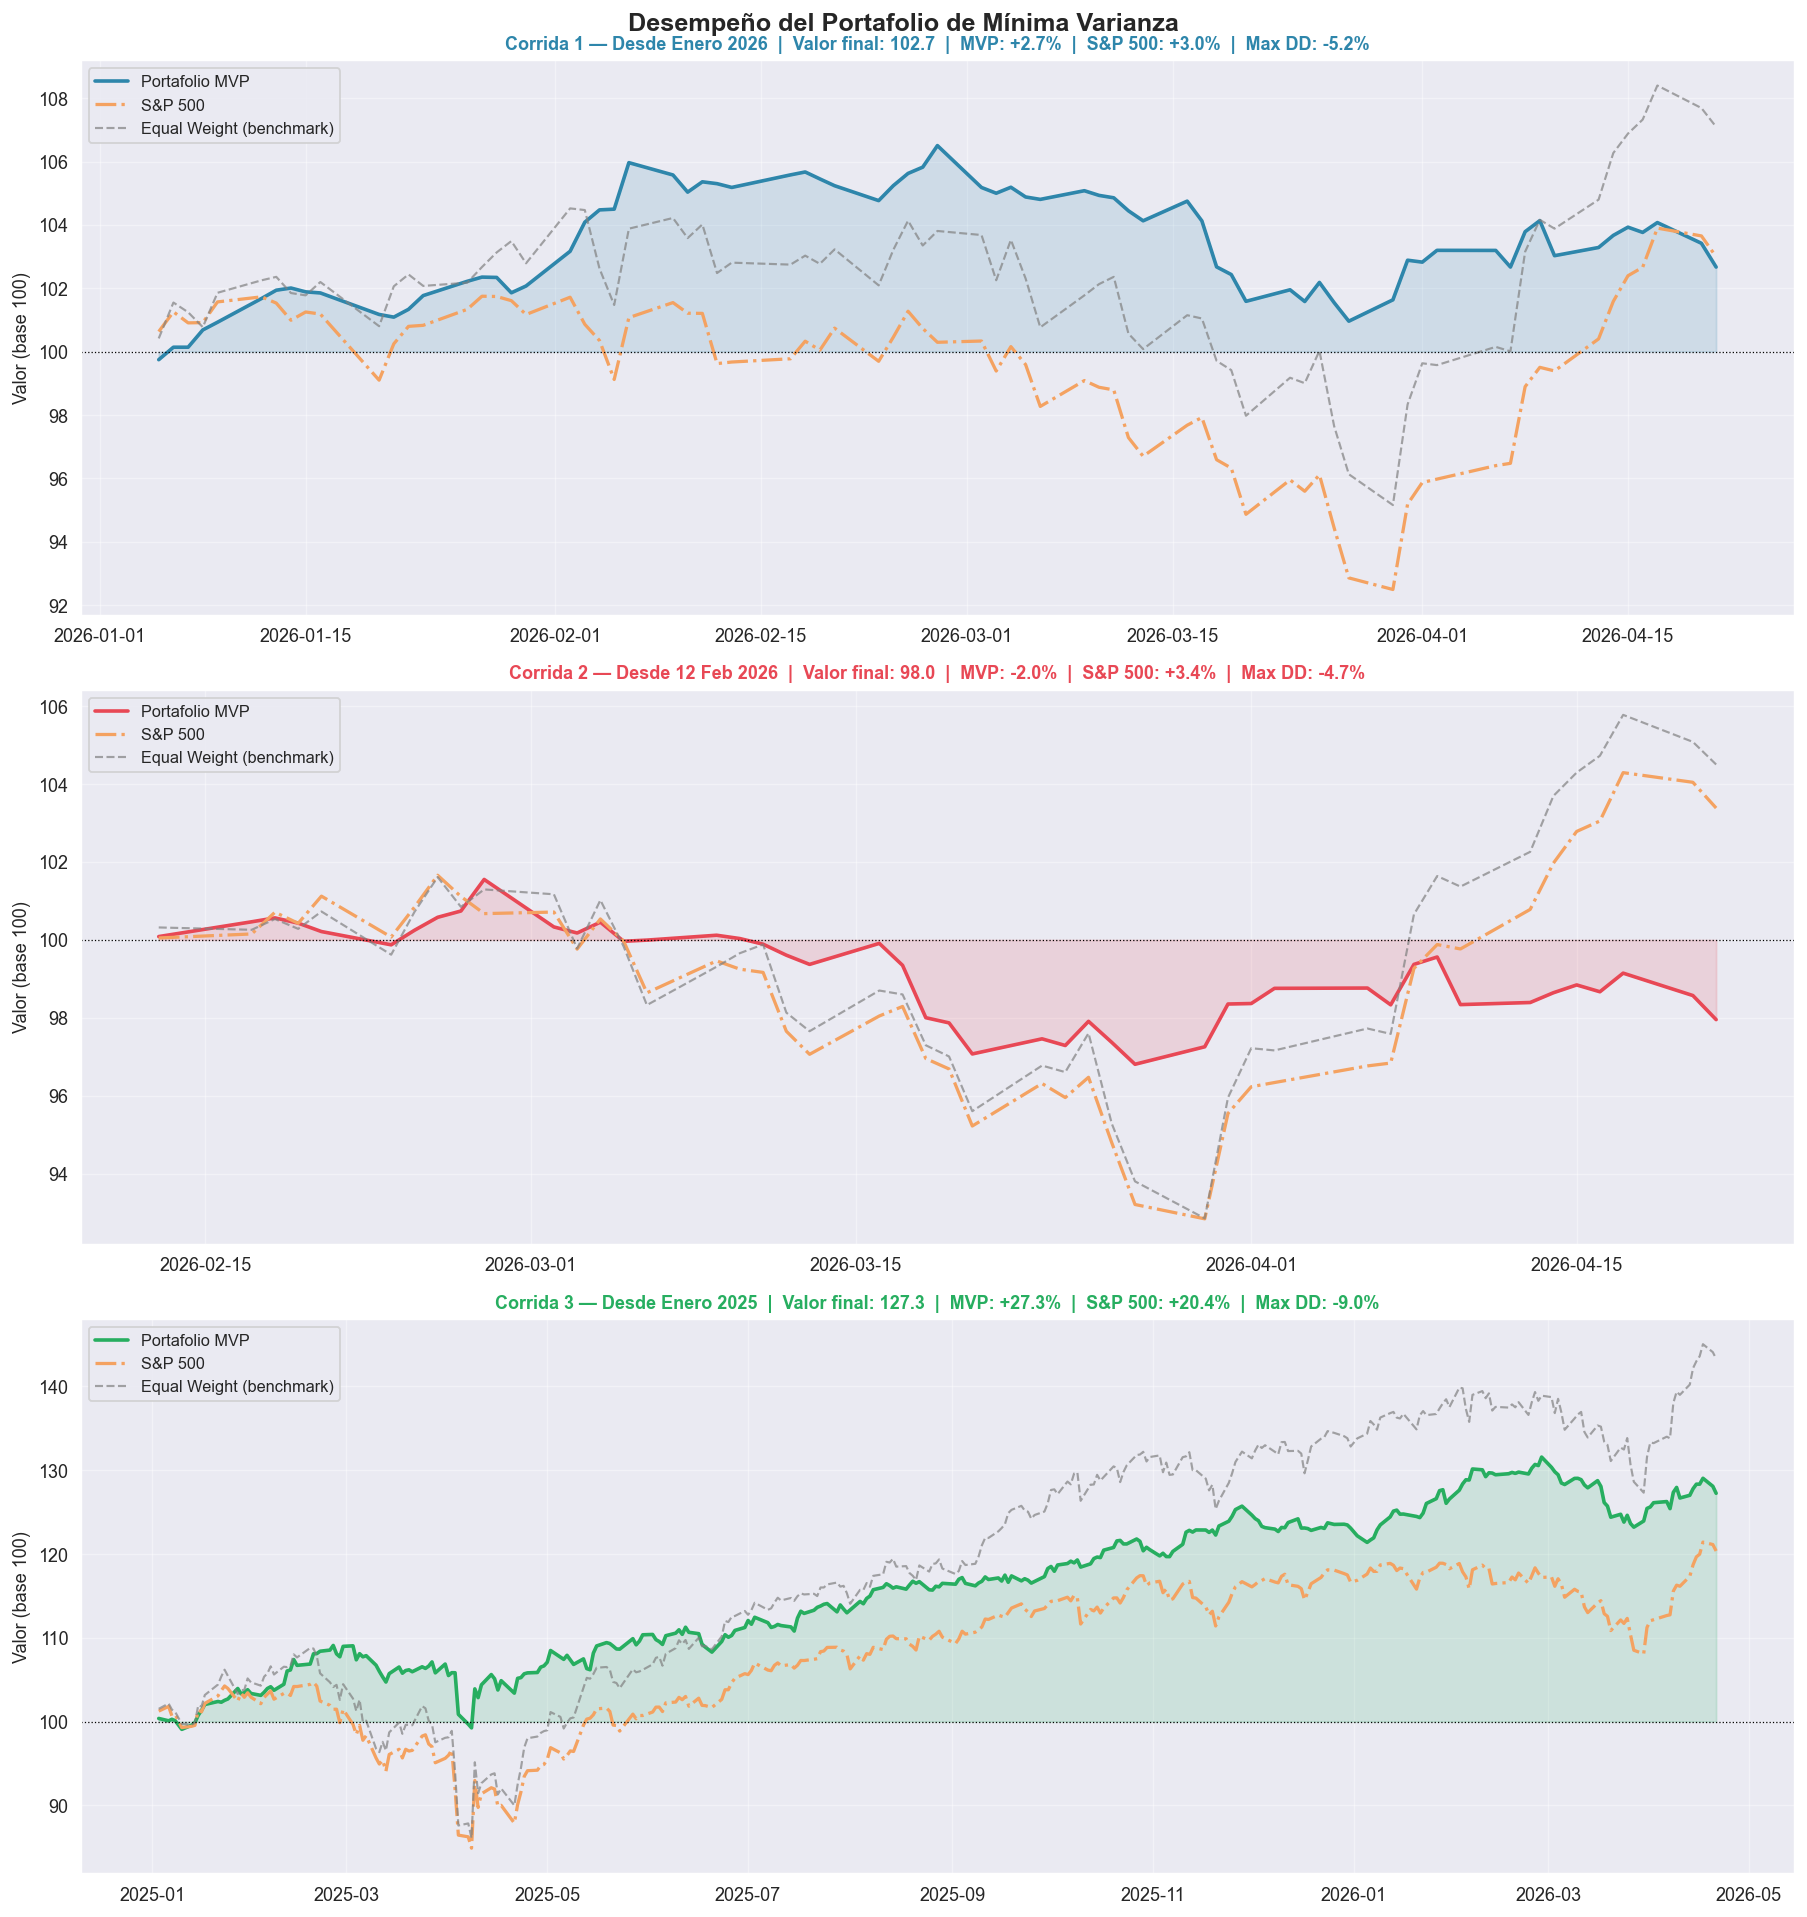

In [ ]:
# ============================================================
# 7. VISUALIZACIÓN — DESEMPEÑO DEL PORTAFOLIO EN EL TIEMPO
# ============================================================

fig, axes = plt.subplots(len(nombres), 1, figsize=(14, 5*len(nombres)), sharex=False)
fig.suptitle('Desempeño del Portafolio de Mínima Varianza', fontsize=14, fontweight='bold')

for ax, (nombre, res), color in zip(axes, resultados.items(), colores):
    cfg     = PERIODOS[nombre]
    pesos   = res['pesos'].values
    ret_log = res['retornos'][res['pesos'].index]

    ret_port  = ret_log @ pesos
    valor     = 100 * np.exp(ret_port.cumsum())
    sp500_val = get_sp500(cfg['start'], cfg['end'])

    ax.fill_between(valor.index, valor, 100, alpha=0.15, color=color)
    ax.plot(valor.index, valor, color=color, linewidth=2, label='Portafolio MVP')
    ax.plot(sp500_val.index, sp500_val, color='#F4A261', linewidth=1.8,
            linestyle='-.', label='S&P 500')

    ret_eq = ret_log.mean(axis=1)
    val_eq = 100 * np.exp(ret_eq.cumsum())
    ax.plot(val_eq.index, val_eq, color='gray', linewidth=1.2,
            linestyle='--', alpha=0.7, label='Equal Weight (benchmark)')

    ax.axhline(100, color='black', linewidth=0.7, linestyle=':')

    rolling_max = valor.cummax()
    drawdown    = (valor - rolling_max) / rolling_max * 100
    dd_max      = drawdown.min()

    fin    = valor.iloc[-1]
    ret_total = fin - 100
    ret_sp    = sp500_val.reindex(valor.index, method='ffill').iloc[-1] - 100
    ax.set_title(
        f'{nombre}  |  Valor final: {fin:.1f}  |  MVP: {ret_total:+.1f}%  |  S&P 500: {ret_sp:+.1f}%  |  Max DD: {dd_max:.1f}%',
        fontsize=10, color=color, fontweight='bold'
    )
    ax.set_ylabel('Valor (base 100)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


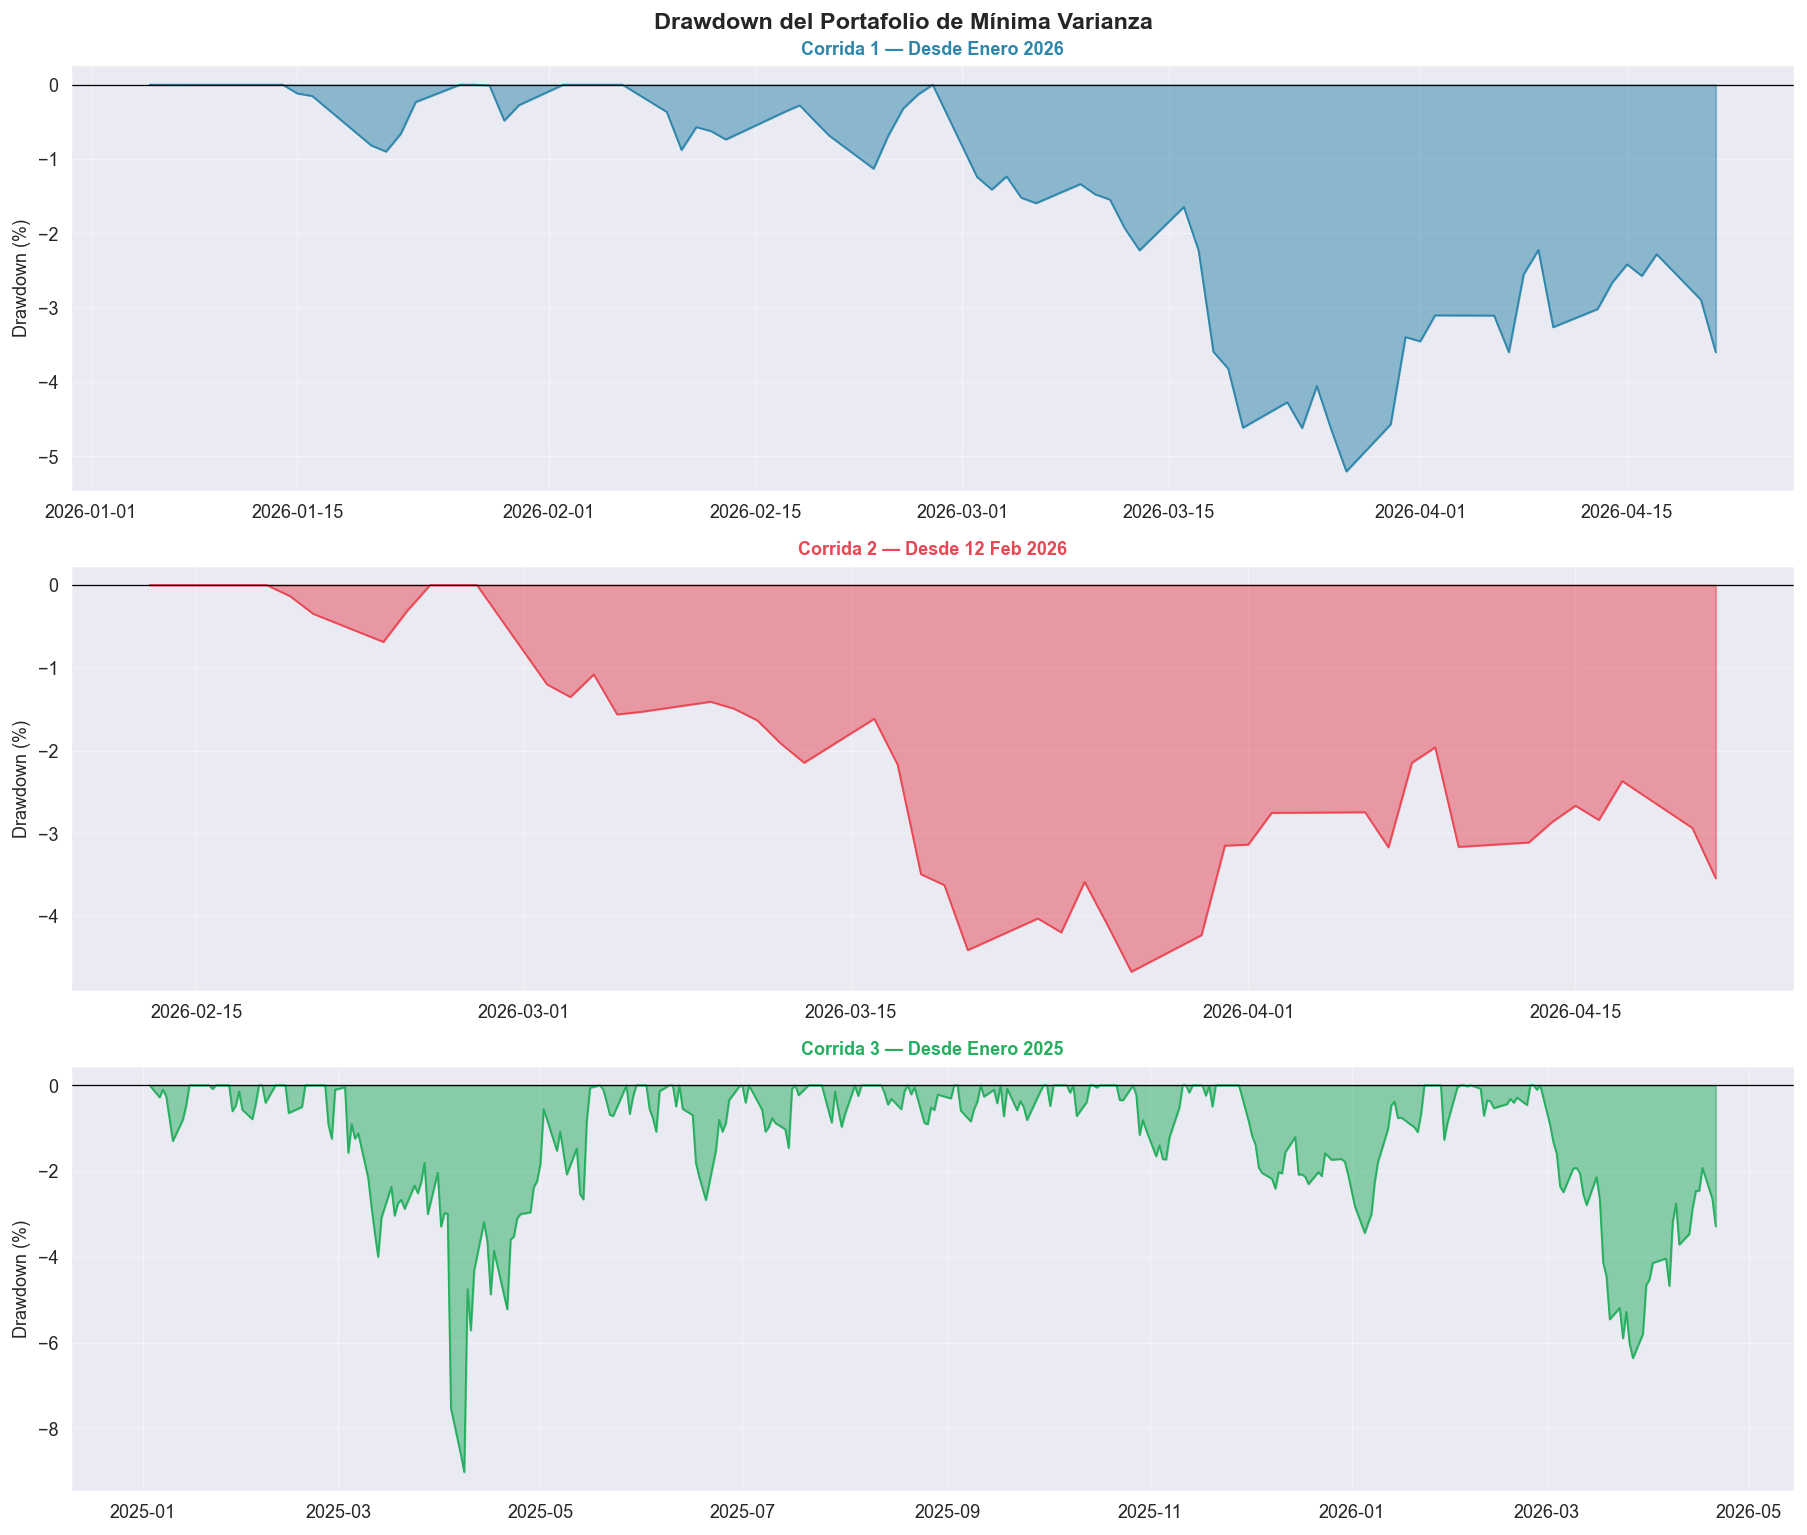

In [ ]:
# ============================================================
# 8. VISUALIZACIÓN — DRAWDOWN
# ============================================================

fig, axes = plt.subplots(len(nombres), 1, figsize=(14, 4*len(nombres)), sharex=False)
fig.suptitle('Drawdown del Portafolio de Mínima Varianza', fontsize=13, fontweight='bold')

for ax, (nombre, res), color in zip(axes, resultados.items(), colores):
    pesos    = res['pesos'].values
    ret_log  = res['retornos'][res['pesos'].index]
    ret_port = ret_log @ pesos
    valor    = 100 * np.exp(ret_port.cumsum())

    rolling_max = valor.cummax()
    drawdown    = (valor - rolling_max) / rolling_max * 100

    ax.fill_between(drawdown.index, drawdown, 0, alpha=0.5, color=color)
    ax.plot(drawdown.index, drawdown, color=color, linewidth=1)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_ylabel('Drawdown (%)')
    ax.set_title(nombre, fontsize=10, color=color, fontweight='bold')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

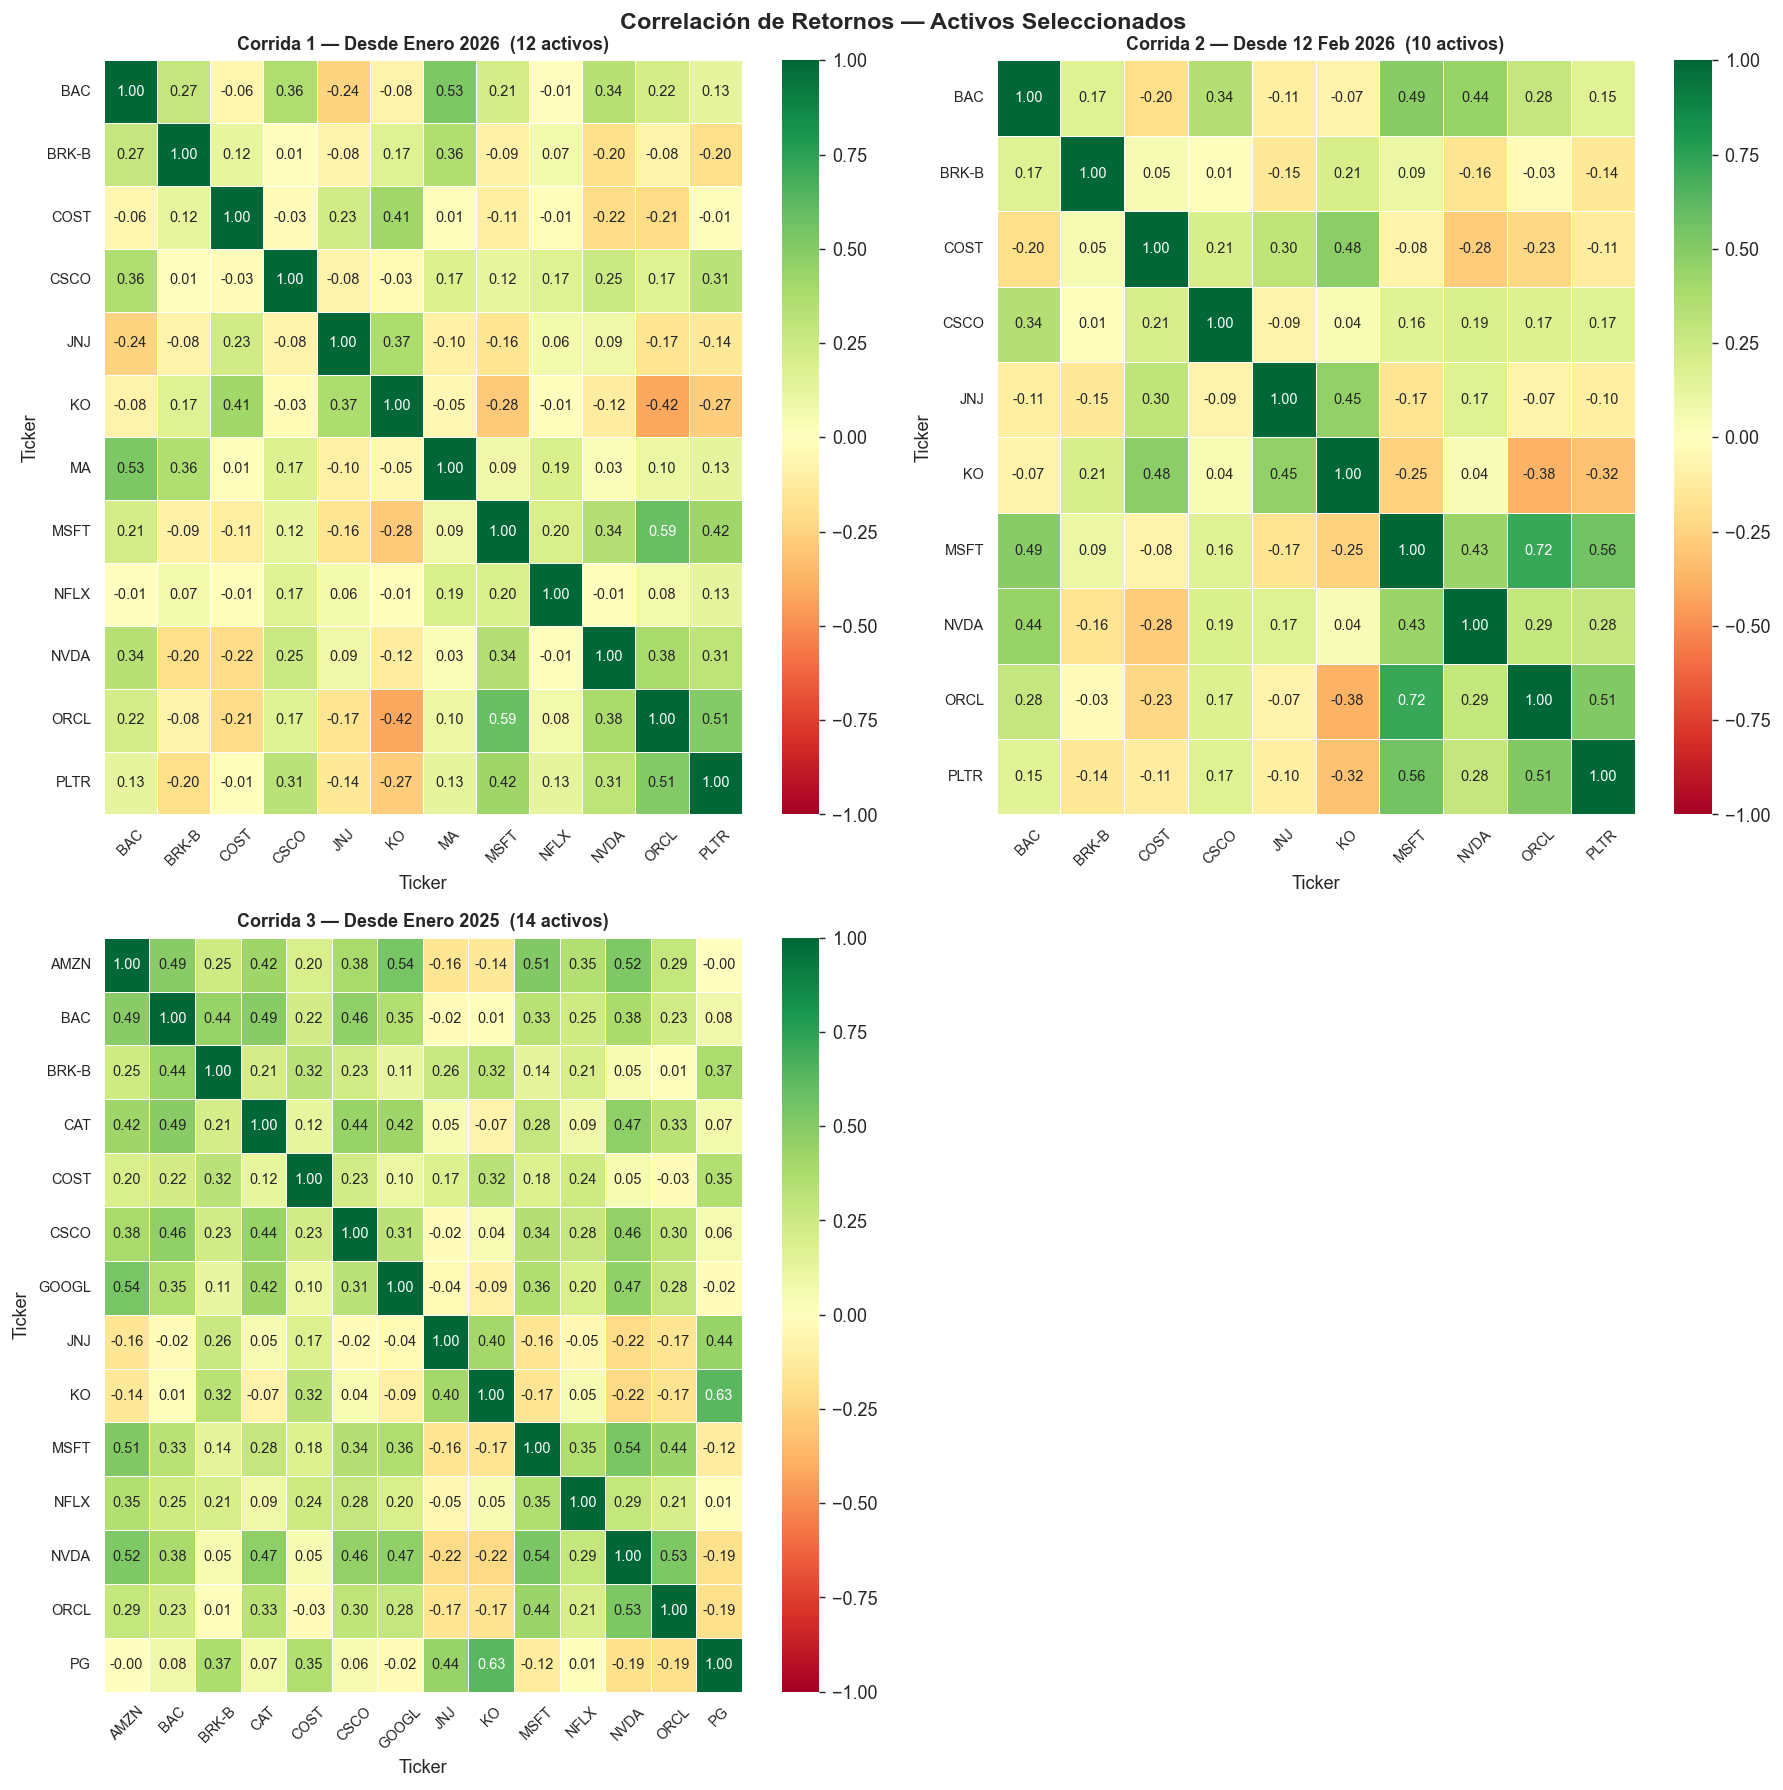

In [ ]:
# ============================================================
# A6. CORRELACIÓN — SOLO ACTIVOS SELECCIONADOS (peso > 0)
# ============================================================
ncols     = 2
nrows     = (len(nombres) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7 * nrows))
axes_flat = axes.flatten()
fig.suptitle('Correlación de Retornos — Activos Seleccionados', fontsize=13, fontweight='bold')

for i, (nombre, res) in enumerate(resultados.items()):
    ax  = axes_flat[i]
    sel = res['pesos'][res['pesos'] > 0.001].index.tolist()
    corr = res['retornos'][sel].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1,
                linewidths=0.4, linecolor='white',
                annot_kws={'size': 8})
    ax.set_title(f'{nombre}  ({len(sel)} activos)',
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

for j in range(len(nombres), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()


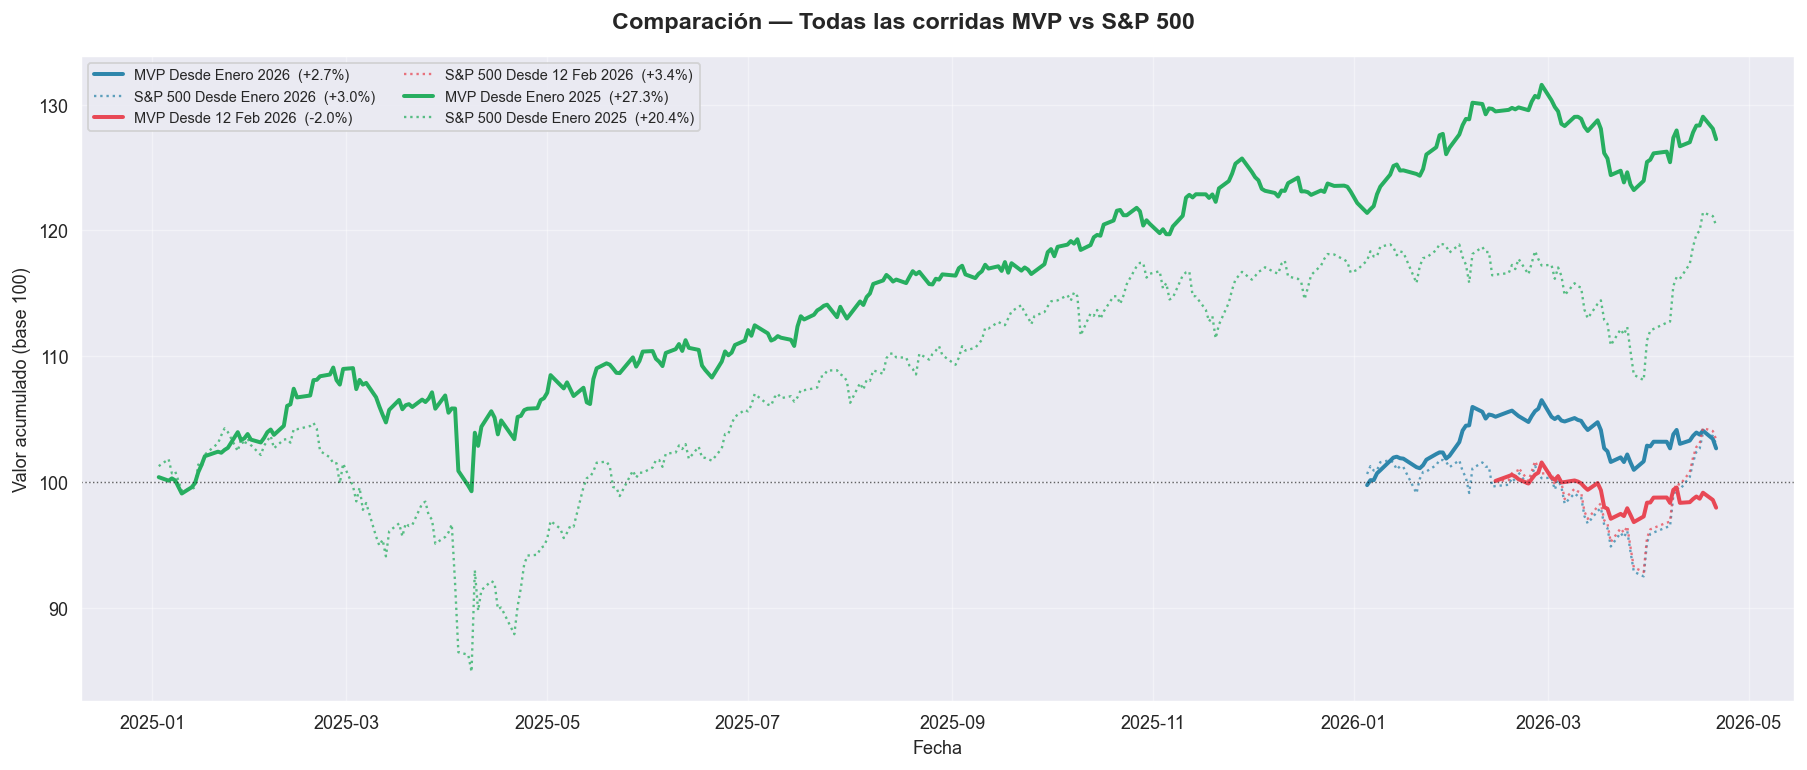

In [ ]:
# ============================================================
# A7. COMPARACIÓN — TODAS LAS CORRIDAS MVP + S&P 500
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Comparación — Todas las corridas MVP vs S&P 500', fontsize=13, fontweight='bold')

for (nombre, res), color in zip(resultados.items(), colores):
    cfg      = PERIODOS[nombre]
    pesos    = res['pesos'].values
    ret_log  = res['retornos'][res['pesos'].index]
    port_val = 100 * np.exp((ret_log @ pesos).cumsum())
    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre

    ax.plot(port_val.index, port_val, color=color, linewidth=2.2,
            label=f'MVP {etiqueta}  ({port_val.iloc[-1]-100:+.1f}%)')

    # S&P 500 sincronizado — empieza en la misma fecha que esta corrida
    sp500_val = get_sp500(cfg['start'], cfg['end'])
    ax.plot(sp500_val.index, sp500_val, color=color, linewidth=1.3,
            linestyle=':', alpha=0.75,
            label=f'S&P 500 {etiqueta}  ({sp500_val.iloc[-1]-100:+.1f}%)')

ax.axhline(100, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_ylabel('Valor acumulado (base 100)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


---
## 📊 SECCIÓN B — Portafolio Filtrado (acciones con peso ≥ 10%)


In [ ]:
# ============================================================
# CÁLCULO DE PORTAFOLIOS FILTRADOS (peso ≥ 10%)  ← base para Sección B
# ============================================================
UMBRAL = 0.10

resultados_filtrados = {}
for nombre, res in resultados.items():
    tickers_10 = res['pesos'][res['pesos'] >= UMBRAL].index.tolist()
    if len(tickers_10) < 2:
        print(f'⚠️  {nombre}: menos de 2 acciones ≥ 10%, omitido.')
        continue
    ret_f = res['retornos'][tickers_10]
    res_f = optimizar_minima_varianza(ret_f, rf_rate=res['rf_rate'])
    resultados_filtrados[nombre] = {
        'precios':  res['precios'][tickers_10],
        'retornos': ret_f,
        **res_f
    }

nombres_f   = list(resultados_filtrados.keys())
etiquetas_f = [n.split('—')[1].strip() if '—' in n else n for n in nombres_f]
colores_f   = [PERIODOS[n]['color'] for n in nombres_f]

print('✅ Portafolios filtrados calculados:')
for n, res in resultados_filtrados.items():
    sel = res['pesos'][res['pesos'] > 0.001].index.tolist()
    print(f'   {n}: {sel}')
    print(f'   Retorno={res["retorno"]*100:.2f}%  Vol={res["volatilidad"]*100:.2f}%  Sharpe={res["sharpe"]:.3f}')


✅ Portafolios filtrados calculados:
   Corrida 1 — Desde Enero 2026: ['BRK-B', 'JNJ', 'KO']
   Retorno=8.76%  Vol=10.80%  Sharpe=0.478
   Corrida 2 — Desde 12 Feb 2026: ['BRK-B', 'JNJ', 'KO']
   Retorno=-35.63%  Vol=10.50%  Sharpe=-3.735
   Corrida 3 — Desde Enero 2025: ['BRK-B', 'JNJ', 'KO', 'MSFT']
   Retorno=16.39%  Vol=11.50%  Sharpe=1.092


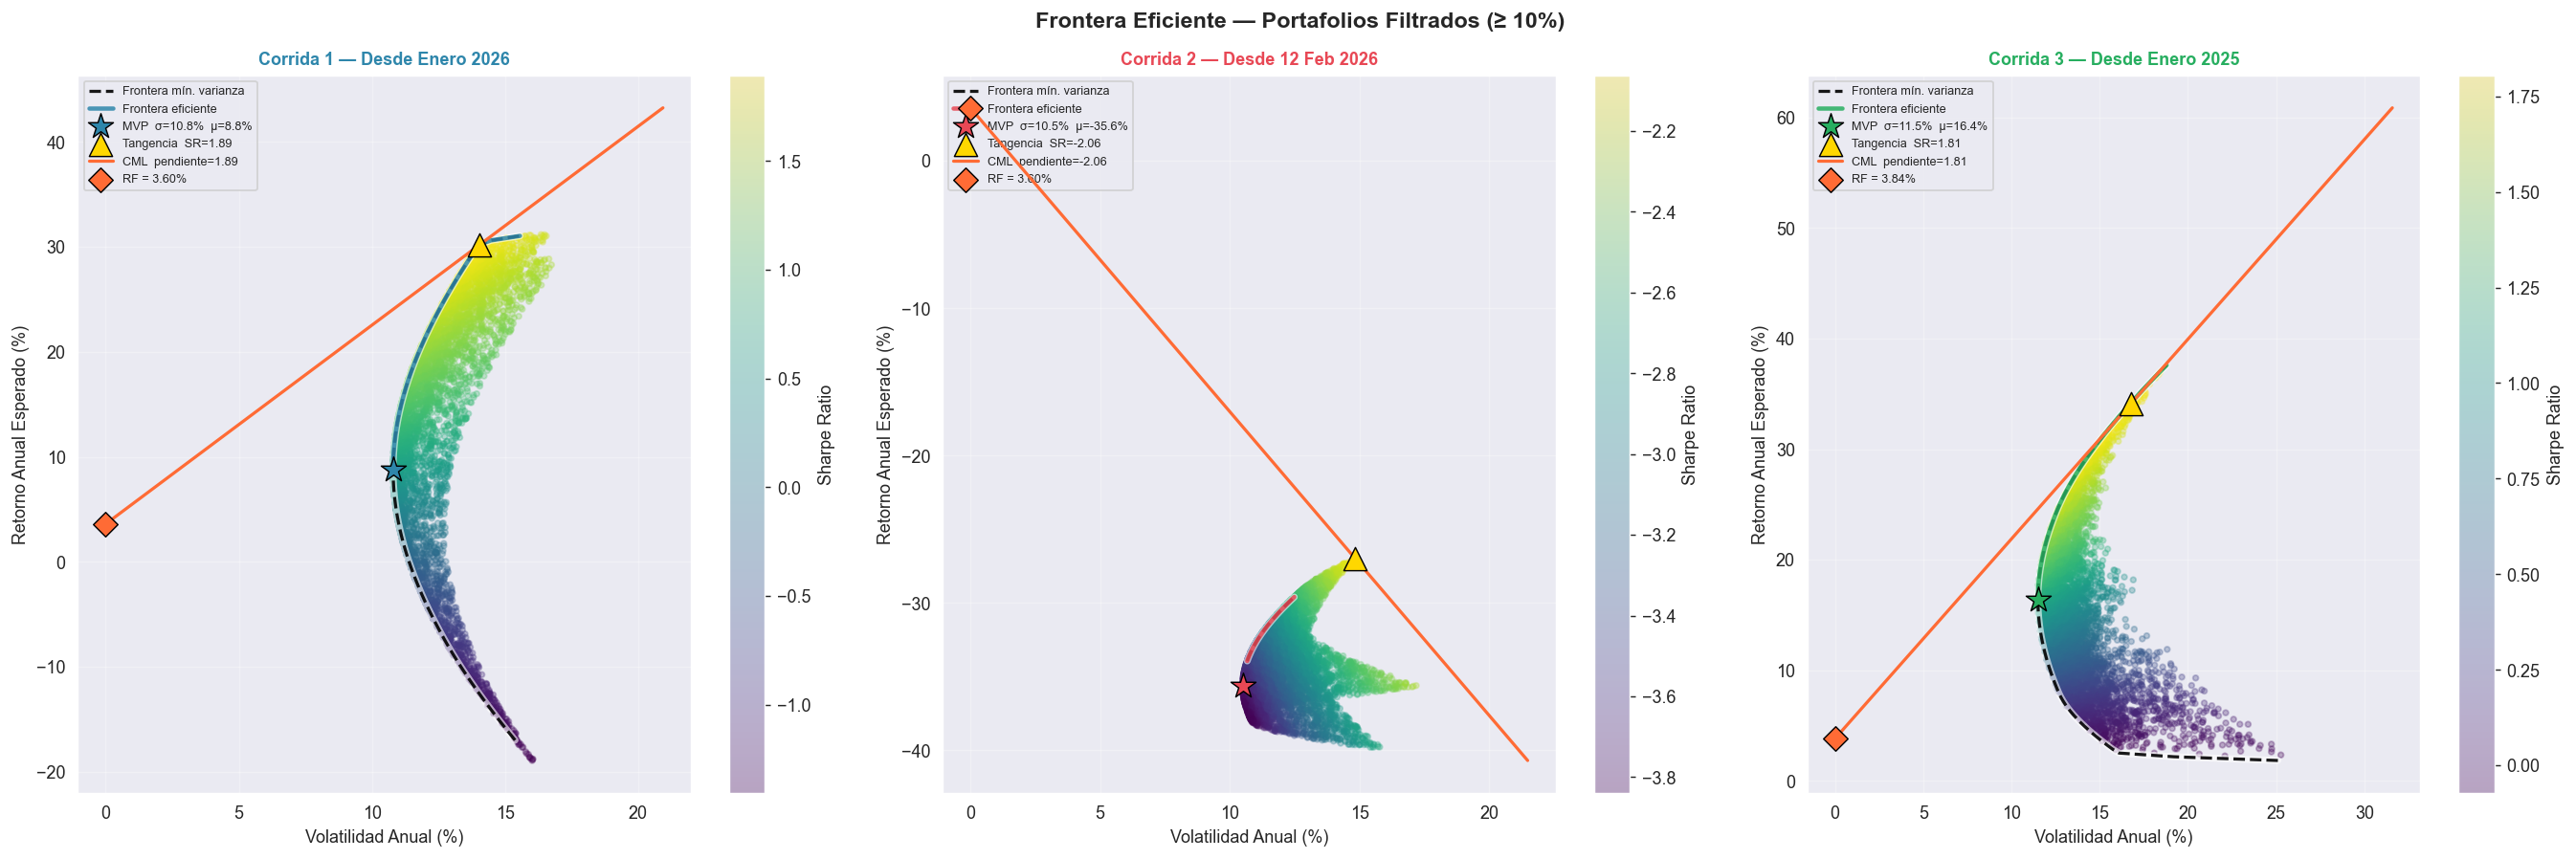

In [ ]:
# ============================================================
# B1. FRONTERA EFICIENTE (filtrado) — Monte Carlo + CML + Curva
# ============================================================
fig, axes = plt.subplots(1, len(nombres_f), figsize=(7 * len(nombres_f), 7))
if len(nombres_f) == 1: axes = [axes]
fig.suptitle('Frontera Eficiente — Portafolios Filtrados (≥ 10%)',
             fontsize=13, fontweight='bold')

for ax, (nombre, res), color in zip(axes, resultados_filtrados.items(), colores_f):
    rets, vols = simular_portafolios(res['media'], res['cov'])
    rf         = res['rf_rate']
    sharpes    = (rets - rf) / vols

    sc = ax.scatter(vols * 100, rets * 100, c=sharpes, cmap='viridis',
                    alpha=0.3, s=10, zorder=1)
    plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

    vfe, rfe = calcular_frontera(res['media'], res['cov'])
    if len(vfe) > 3:
        ax.plot(vfe * 100, rfe * 100, 'w-',  linewidth=4.0, zorder=3, alpha=0.6)
        ax.plot(vfe * 100, rfe * 100, 'k--', linewidth=1.8, zorder=4,
                label='Frontera mín. varianza', alpha=0.9)
        mask = rfe >= res['retorno']
        if mask.any():
            ax.plot(vfe[mask] * 100, rfe[mask] * 100, color=color,
                    linewidth=2.5, zorder=5, alpha=0.85, label='Frontera eficiente')

    ax.scatter(res['volatilidad'] * 100, res['retorno'] * 100,
               color=color, s=230, zorder=7, marker='*',
               edgecolors='black', linewidths=0.8,
               label=f'MVP  σ={res["volatilidad"]*100:.1f}%  μ={res["retorno"]*100:.1f}%')

    idx_tan    = np.argmax(sharpes)
    vol_tan    = vols[idx_tan] * 100
    ret_tan    = rets[idx_tan] * 100
    sharpe_tan = sharpes[idx_tan]
    ax.scatter(vol_tan, ret_tan, color='gold', s=180, zorder=7, marker='^',
               edgecolors='black', linewidths=0.8,
               label=f'Tangencia  SR={sharpe_tan:.2f}')

    vol_cml = np.linspace(0, vols.max() * 100 * 1.25, 300)
    ret_cml = rf * 100 + sharpe_tan * vol_cml
    ax.plot(vol_cml, ret_cml, color='#FF6B35', linewidth=1.8, zorder=6,
            label=f'CML  pendiente={sharpe_tan:.2f}')
    ax.scatter(0, rf * 100, color='#FF6B35', s=100, zorder=8, marker='D',
               edgecolors='black', linewidths=0.8, label=f'RF = {rf*100:.2f}%')

    ax.set_xlabel('Volatilidad Anual (%)')
    ax.set_ylabel('Retorno Anual Esperado (%)')
    ax.set_title(nombre, fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


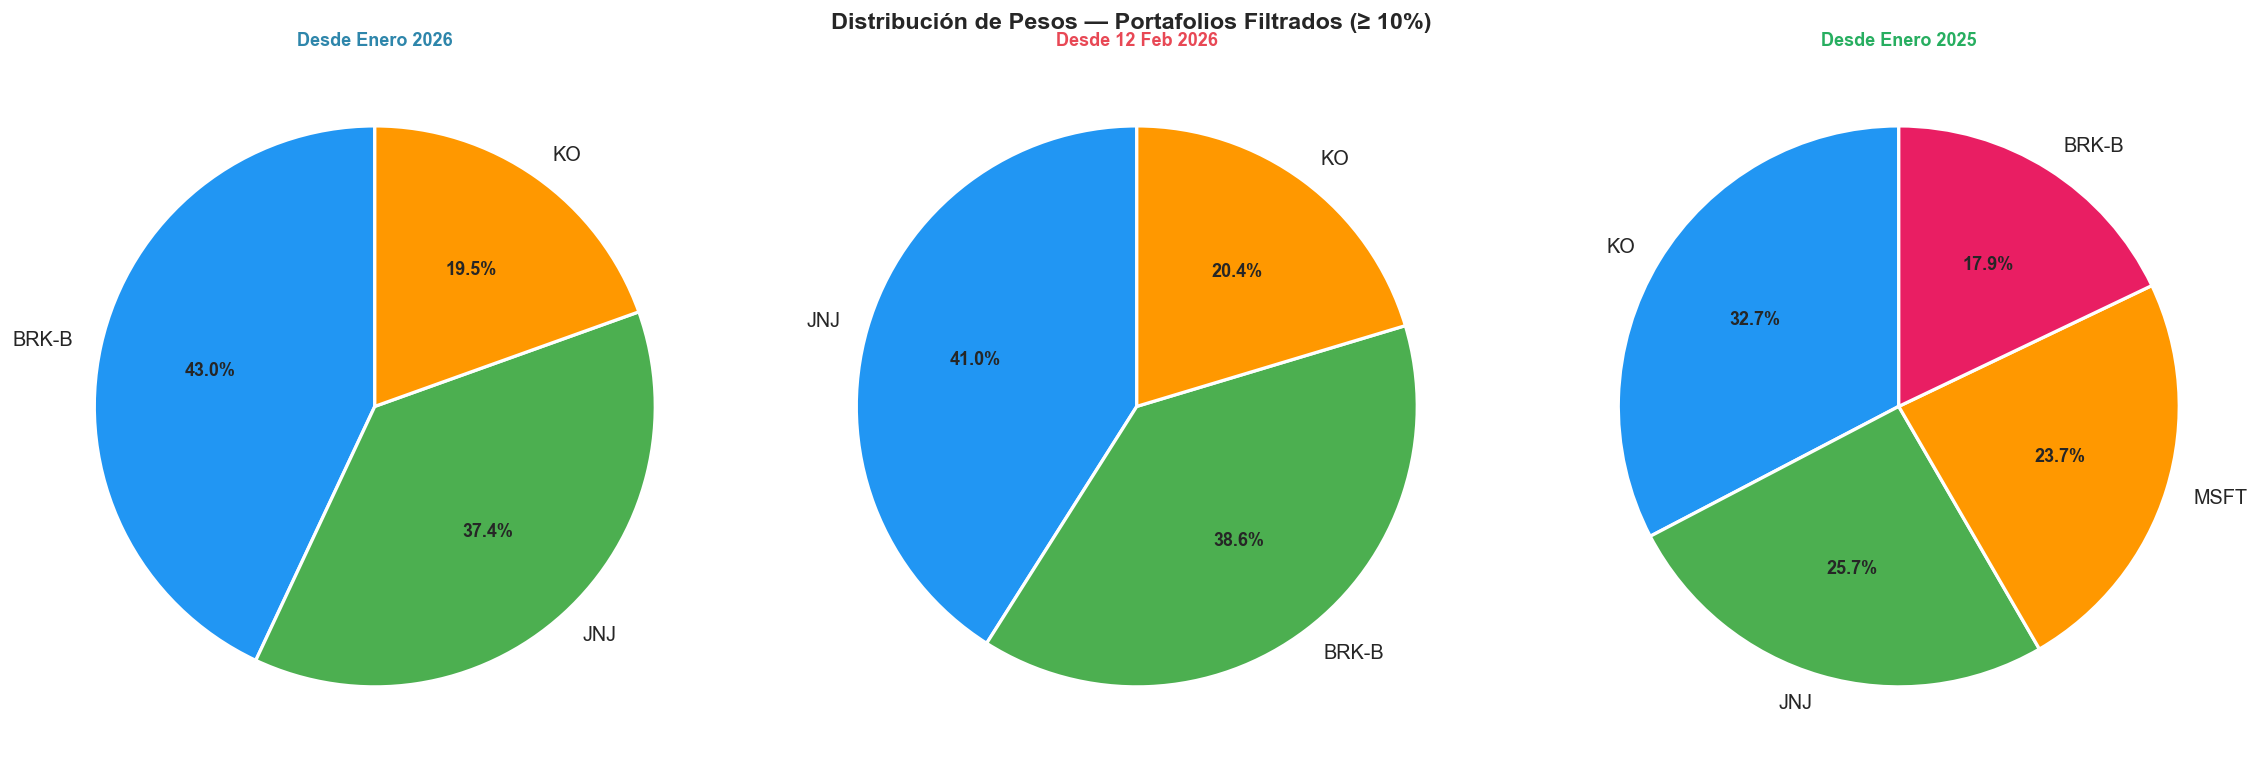

In [ ]:
# ============================================================
# B2. PESOS FILTRADOS — GRÁFICO DE PASTEL
# ============================================================
fig, axes = plt.subplots(1, len(nombres_f), figsize=(6 * len(nombres_f), 6))
if len(nombres_f) == 1: axes = [axes]
fig.suptitle('Distribución de Pesos — Portafolios Filtrados (≥ 10%)',
             fontsize=13, fontweight='bold')

palette = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for i, (nombre, color) in enumerate(zip(nombres_f, colores_f)):
    ax    = axes[i]
    pesos = resultados_filtrados[nombre]['pesos'].sort_values(ascending=False)
    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre

    wedges, texts, autotexts = ax.pie(
        pesos.values,
        labels=pesos.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=palette[:len(pesos)],
        wedgeprops=dict(edgecolor='white', linewidth=1.8),
        textprops={'fontsize': 11}
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight('bold')
    ax.set_title(etiqueta, fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
plt.show()


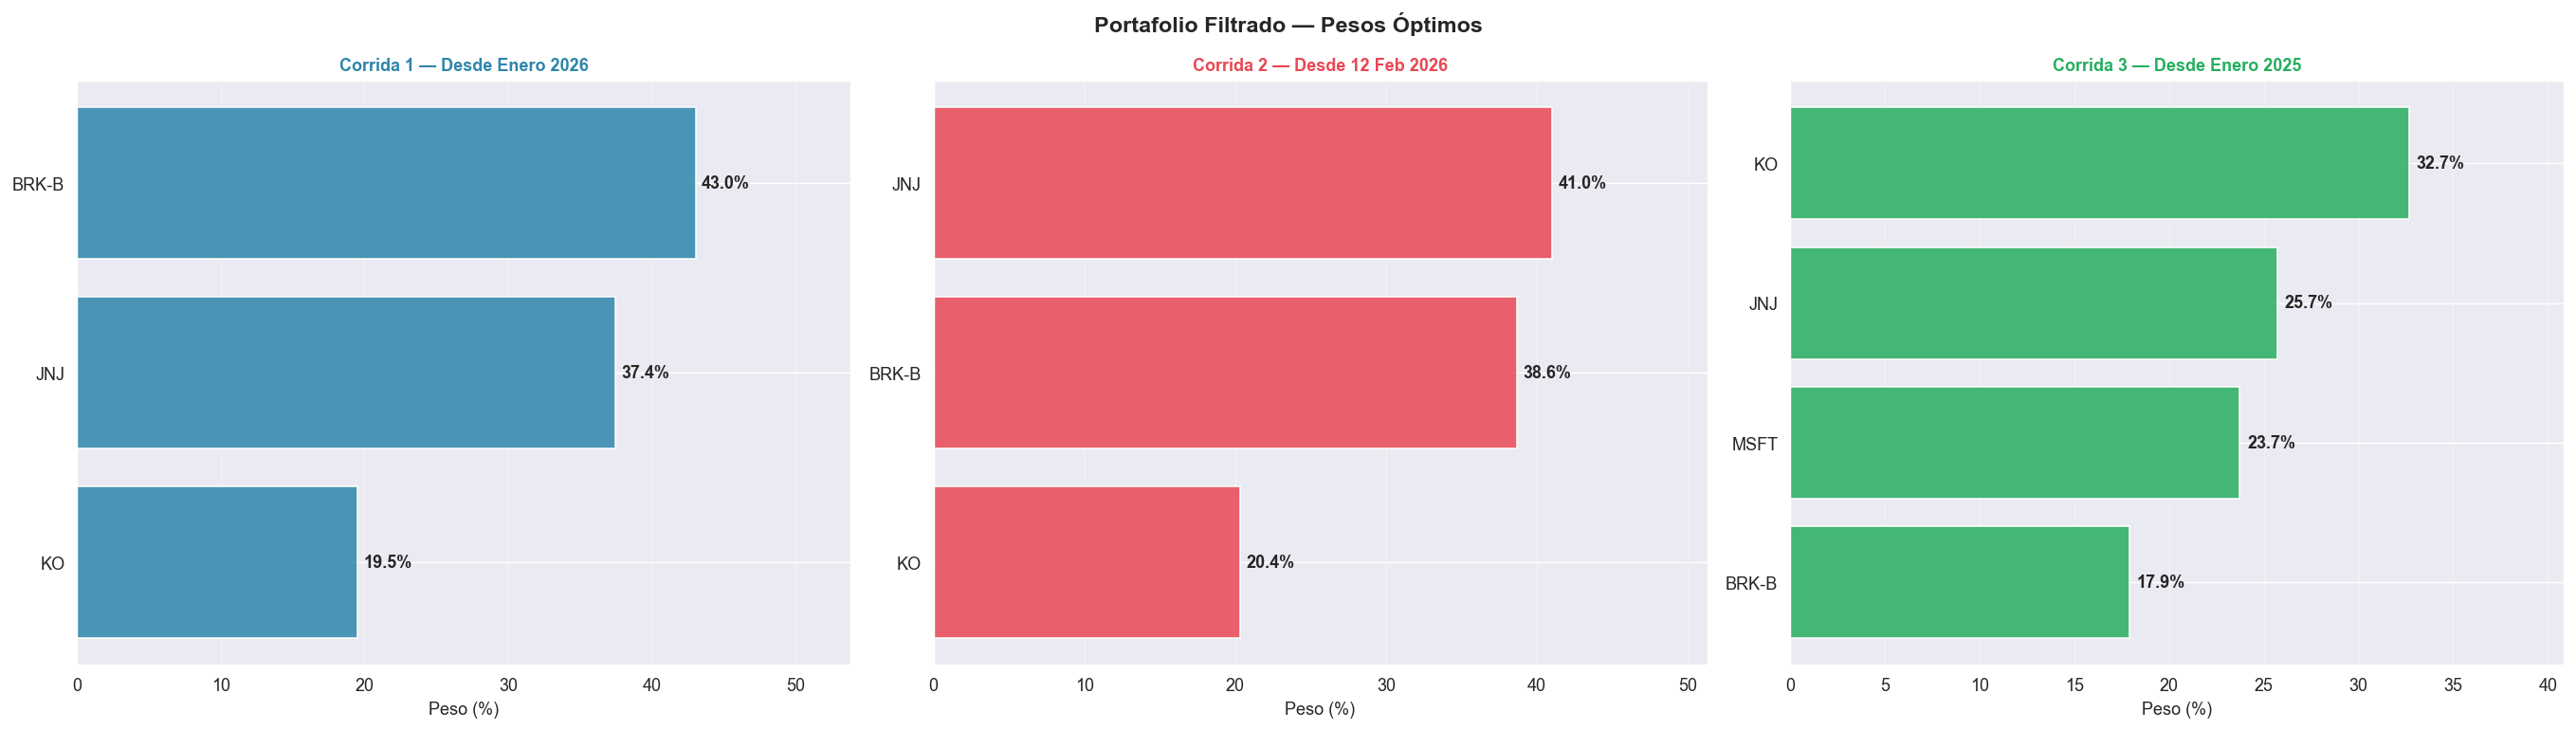


📊 MÉTRICAS DEL PORTAFOLIO FILTRADO
                  Retorno Anual (%) Volatilidad (%) Sharpe Ratio
Período                                                         
Desde Enero 2026               8.76           10.80        0.478
Desde 12 Feb 2026            -35.63           10.50       -3.735
Desde Enero 2025              16.39           11.50        1.092


In [ ]:
# ============================================================
# B3. PESOS FILTRADOS + MÉTRICAS (tabla)
# ============================================================
fig, axes = plt.subplots(1, len(nombres_f), figsize=(7 * len(nombres_f), 6))
if len(nombres_f) == 1: axes = [axes]
fig.suptitle('Portafolio Filtrado — Pesos Óptimos', fontsize=13, fontweight='bold')

for col, (nombre, color) in enumerate(zip(nombres_f, colores_f)):
    res   = resultados_filtrados[nombre]
    ax_w  = axes[col]
    pesos = res['pesos'].sort_values(ascending=True)
    bars  = ax_w.barh(pesos.index, pesos.values * 100, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, pesos.values):
        ax_w.text(val * 100 + 0.4, bar.get_y() + bar.get_height() / 2,
                  f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax_w.set_xlabel('Peso (%)')
    ax_w.set_title(nombre, fontsize=10, color=color, fontweight='bold')
    ax_w.set_xlim(0, pesos.values.max() * 125)
    ax_w.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ── Tabla de métricas ─────────────────────────────────────────────
print('\n📊 MÉTRICAS DEL PORTAFOLIO FILTRADO')
print('=' * 55)
mf = pd.DataFrame([
    {
        'Período':           lbl,
        'Retorno Anual (%)': f"{resultados_filtrados[n]['retorno']*100:.2f}",
        'Volatilidad (%)':   f"{resultados_filtrados[n]['volatilidad']*100:.2f}",
        'Sharpe Ratio':      f"{resultados_filtrados[n]['sharpe']:.3f}"
    }
    for lbl, n in zip(etiquetas_f, nombres_f)
]).set_index('Período')
print(mf.to_string())


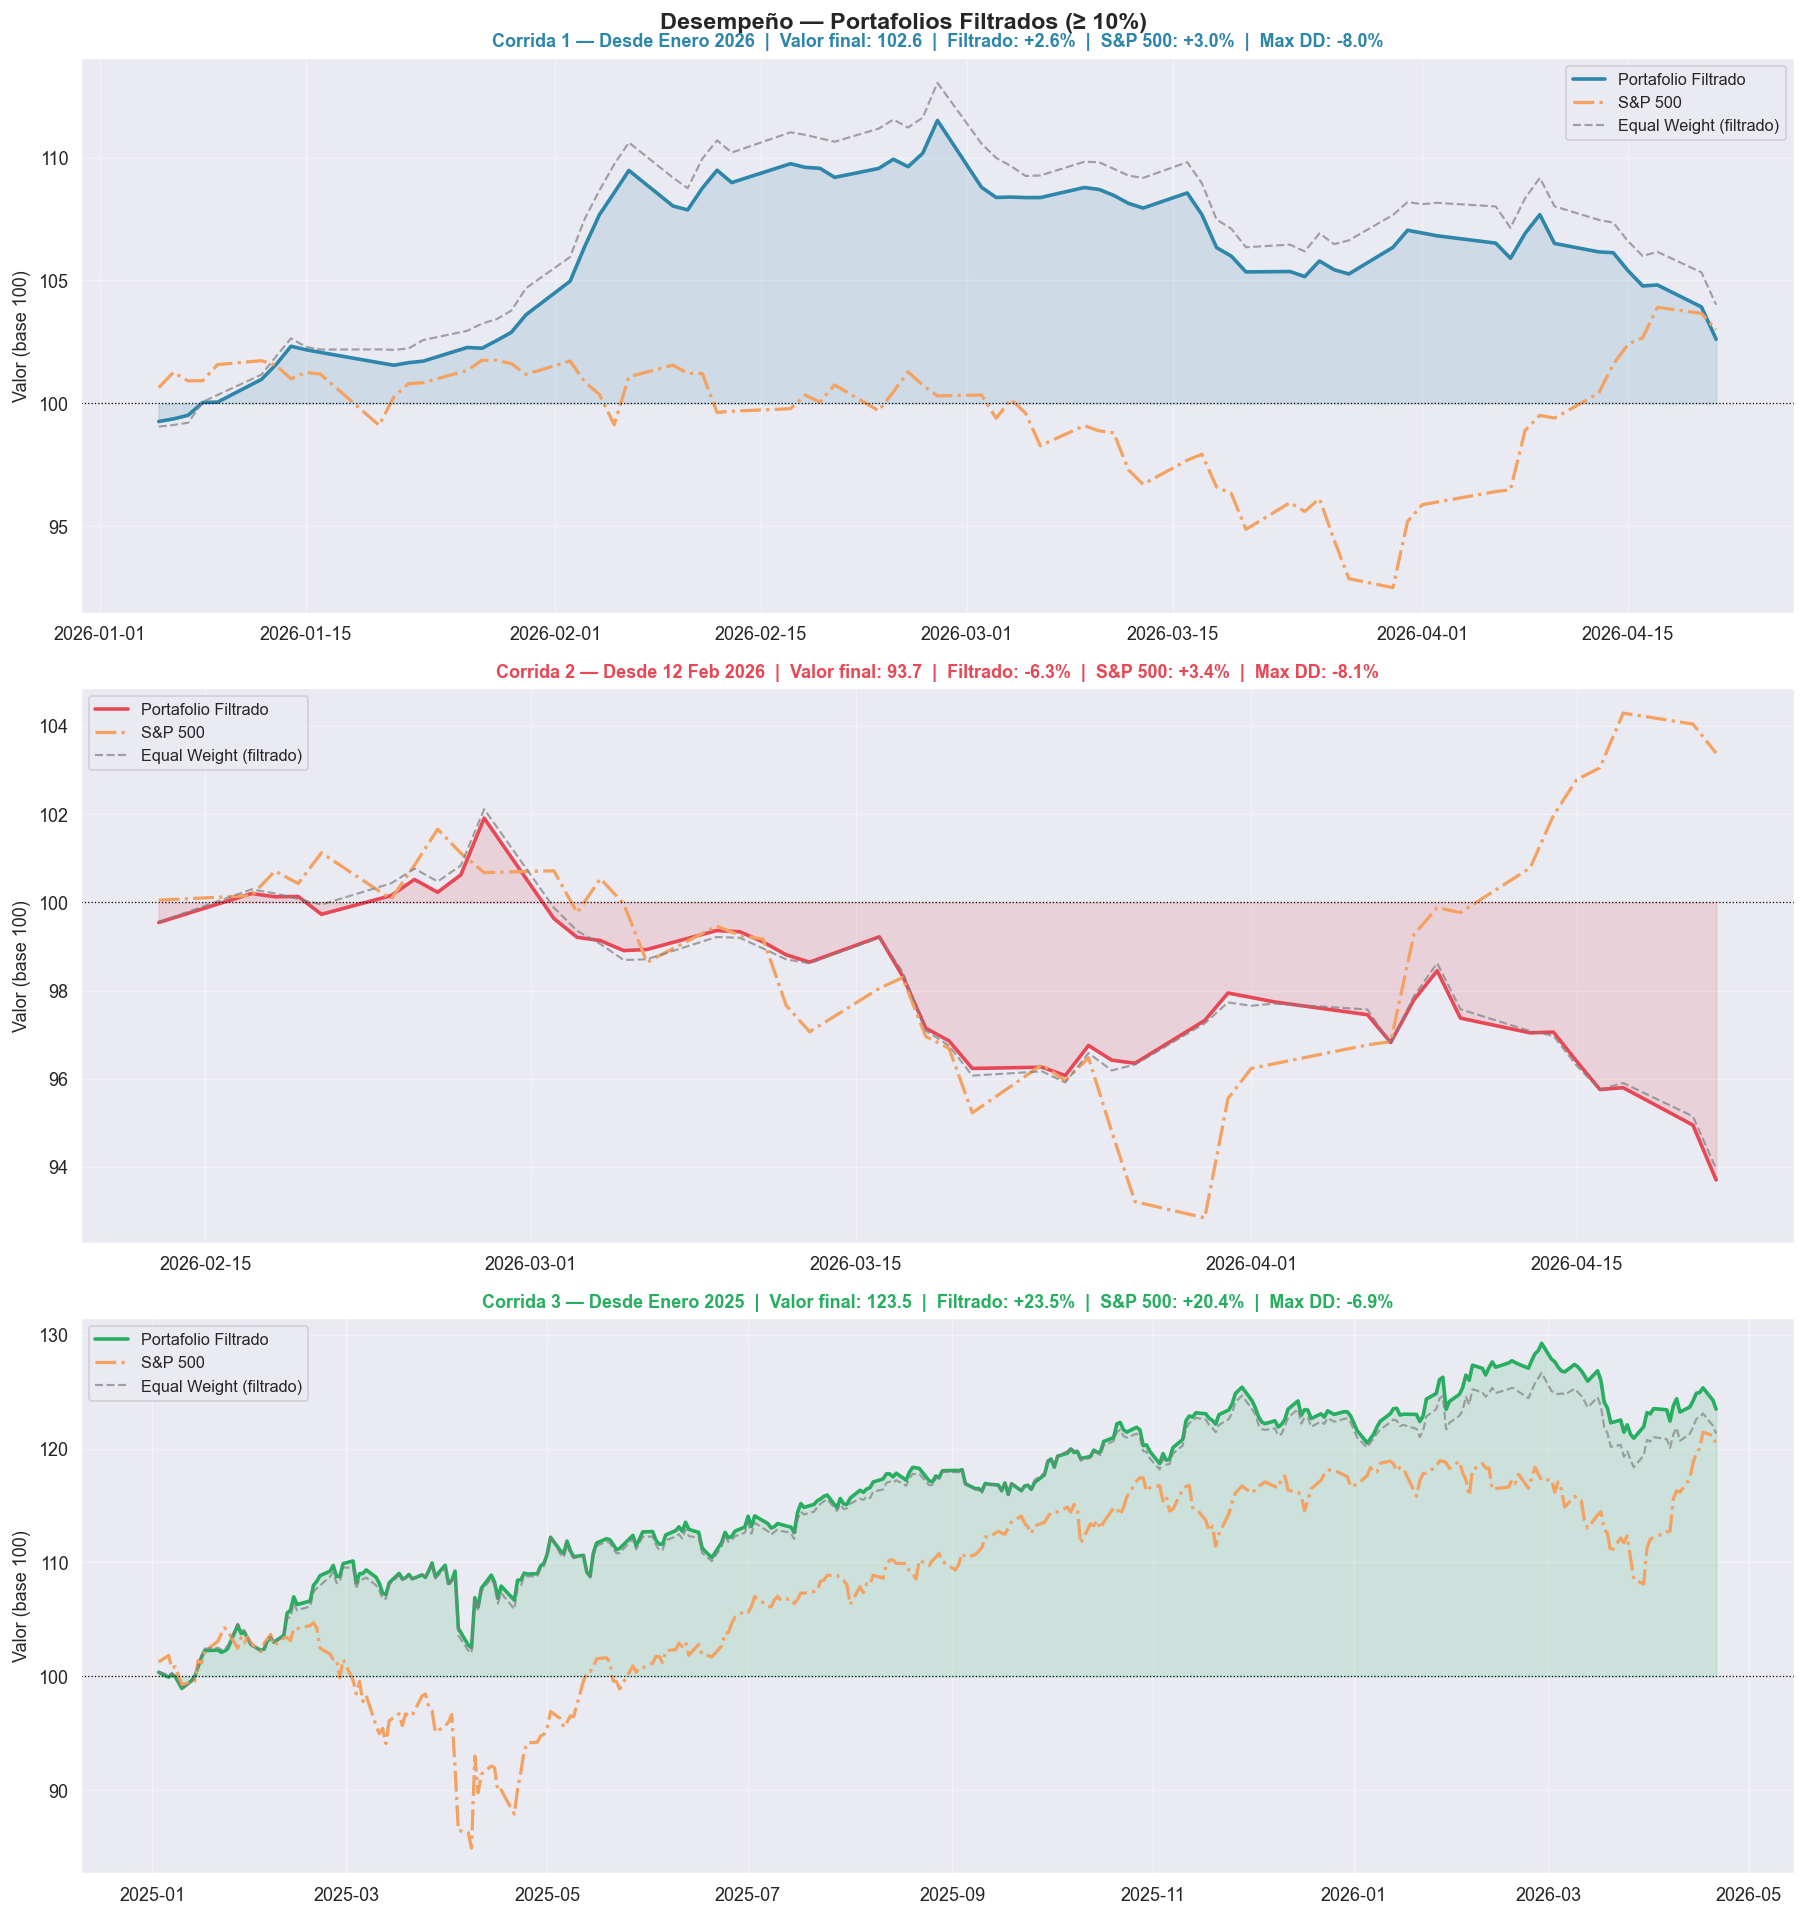

In [ ]:
# ============================================================
# B4. DESEMPEÑO — PORTAFOLIOS FILTRADOS
# ============================================================
fig, axes = plt.subplots(len(nombres_f), 1, figsize=(14, 5 * len(nombres_f)), sharex=False)
if len(nombres_f) == 1: axes = [axes]
fig.suptitle('Desempeño — Portafolios Filtrados (≥ 10%)', fontsize=13, fontweight='bold')

for ax, (nombre, res), color in zip(axes, resultados_filtrados.items(), colores_f):
    cfg      = PERIODOS[nombre]
    pesos    = res['pesos'].values
    ret_log  = res['retornos'][res['pesos'].index]
    ret_port = ret_log @ pesos
    valor    = 100 * np.exp(ret_port.cumsum())

    sp500_val   = get_sp500(cfg['start'], cfg['end'])
    ret_eq      = ret_log.mean(axis=1)
    eq_val      = 100 * np.exp(ret_eq.cumsum())
    rolling_max = valor.cummax()
    dd_max      = ((valor - rolling_max) / rolling_max * 100).min()

    ax.fill_between(valor.index, valor, 100, alpha=0.15, color=color)
    ax.plot(valor.index,     valor,     color=color,      linewidth=2,   label='Portafolio Filtrado')
    ax.plot(sp500_val.index, sp500_val, color='#F4A261',  linewidth=1.8,
            linestyle='-.', label='S&P 500')
    ax.plot(eq_val.index,    eq_val,    color='gray',     linewidth=1.2,
            linestyle='--', alpha=0.7, label='Equal Weight (filtrado)')
    ax.axhline(100, color='black', linewidth=0.7, linestyle=':')

    fin    = valor.iloc[-1]
    ret_sp = sp500_val.reindex(valor.index, method='ffill').iloc[-1] - 100
    ax.set_title(
        f'{nombre}  |  Valor final: {fin:.1f}  |  Filtrado: {fin-100:+.1f}%  |  S&P 500: {ret_sp:+.1f}%  |  Max DD: {dd_max:.1f}%',
        fontsize=10, color=color, fontweight='bold')
    ax.set_ylabel('Valor (base 100)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


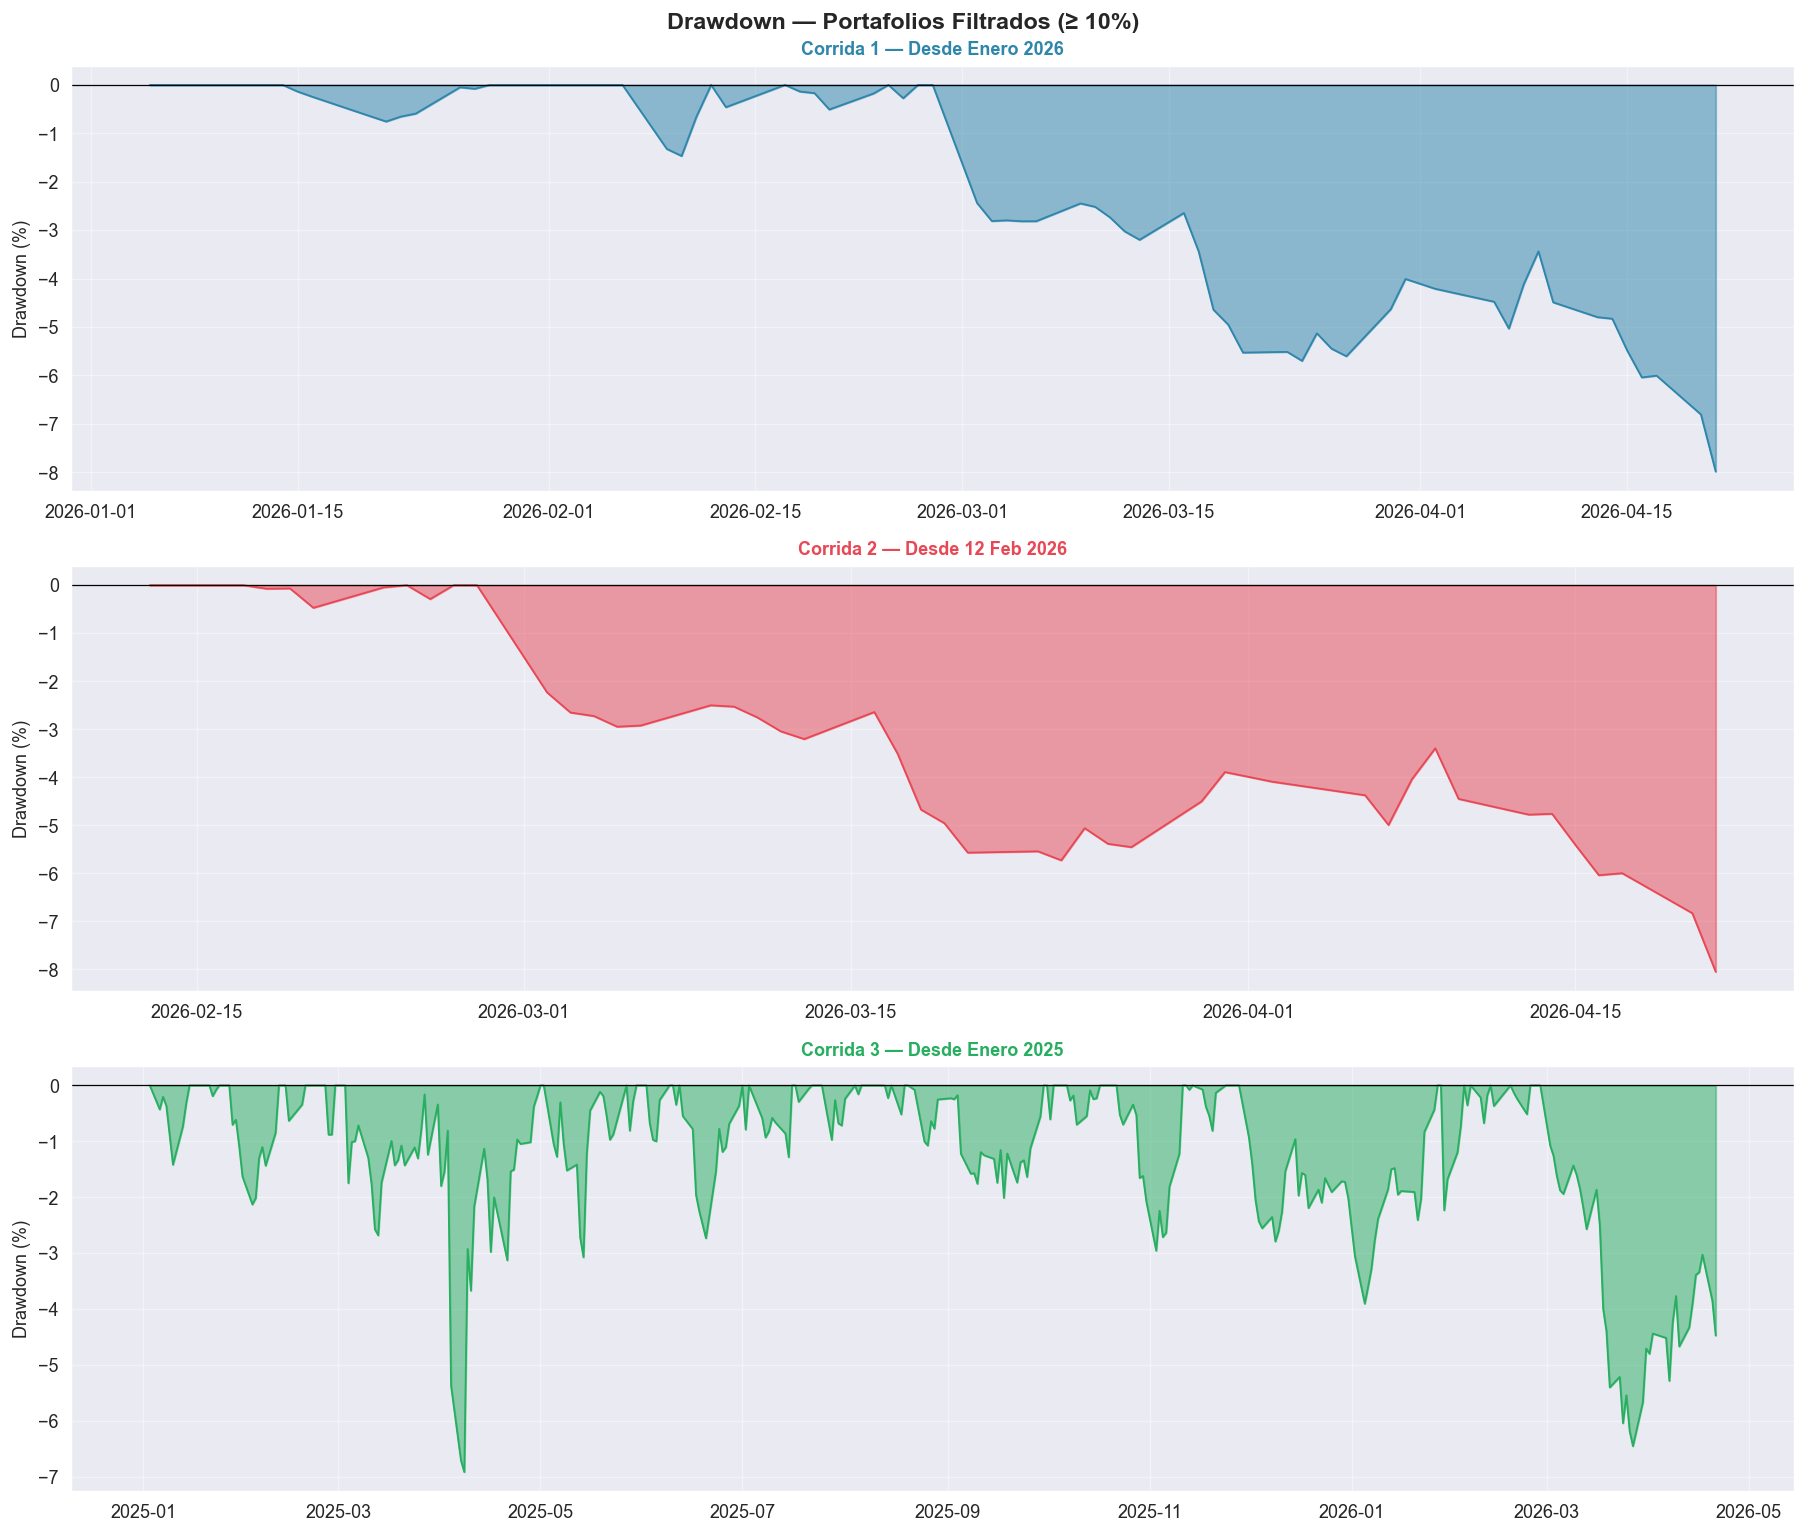

In [ ]:
# ============================================================
# B5. DRAWDOWN — PORTAFOLIOS FILTRADOS
# ============================================================
fig, axes = plt.subplots(len(nombres_f), 1, figsize=(14, 4 * len(nombres_f)), sharex=False)
if len(nombres_f) == 1: axes = [axes]
fig.suptitle('Drawdown — Portafolios Filtrados (≥ 10%)', fontsize=13, fontweight='bold')

for ax, (nombre, res), color in zip(axes, resultados_filtrados.items(), colores_f):
    pesos    = res['pesos'].values
    ret_log  = res['retornos'][res['pesos'].index]
    ret_port = ret_log @ pesos
    valor    = 100 * np.exp(ret_port.cumsum())

    rolling_max = valor.cummax()
    drawdown    = (valor - rolling_max) / rolling_max * 100

    ax.fill_between(drawdown.index, drawdown, 0, alpha=0.5, color=color)
    ax.plot(drawdown.index, drawdown, color=color, linewidth=1)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_ylabel('Drawdown (%)')
    ax.set_title(nombre, fontsize=10, color=color, fontweight='bold')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


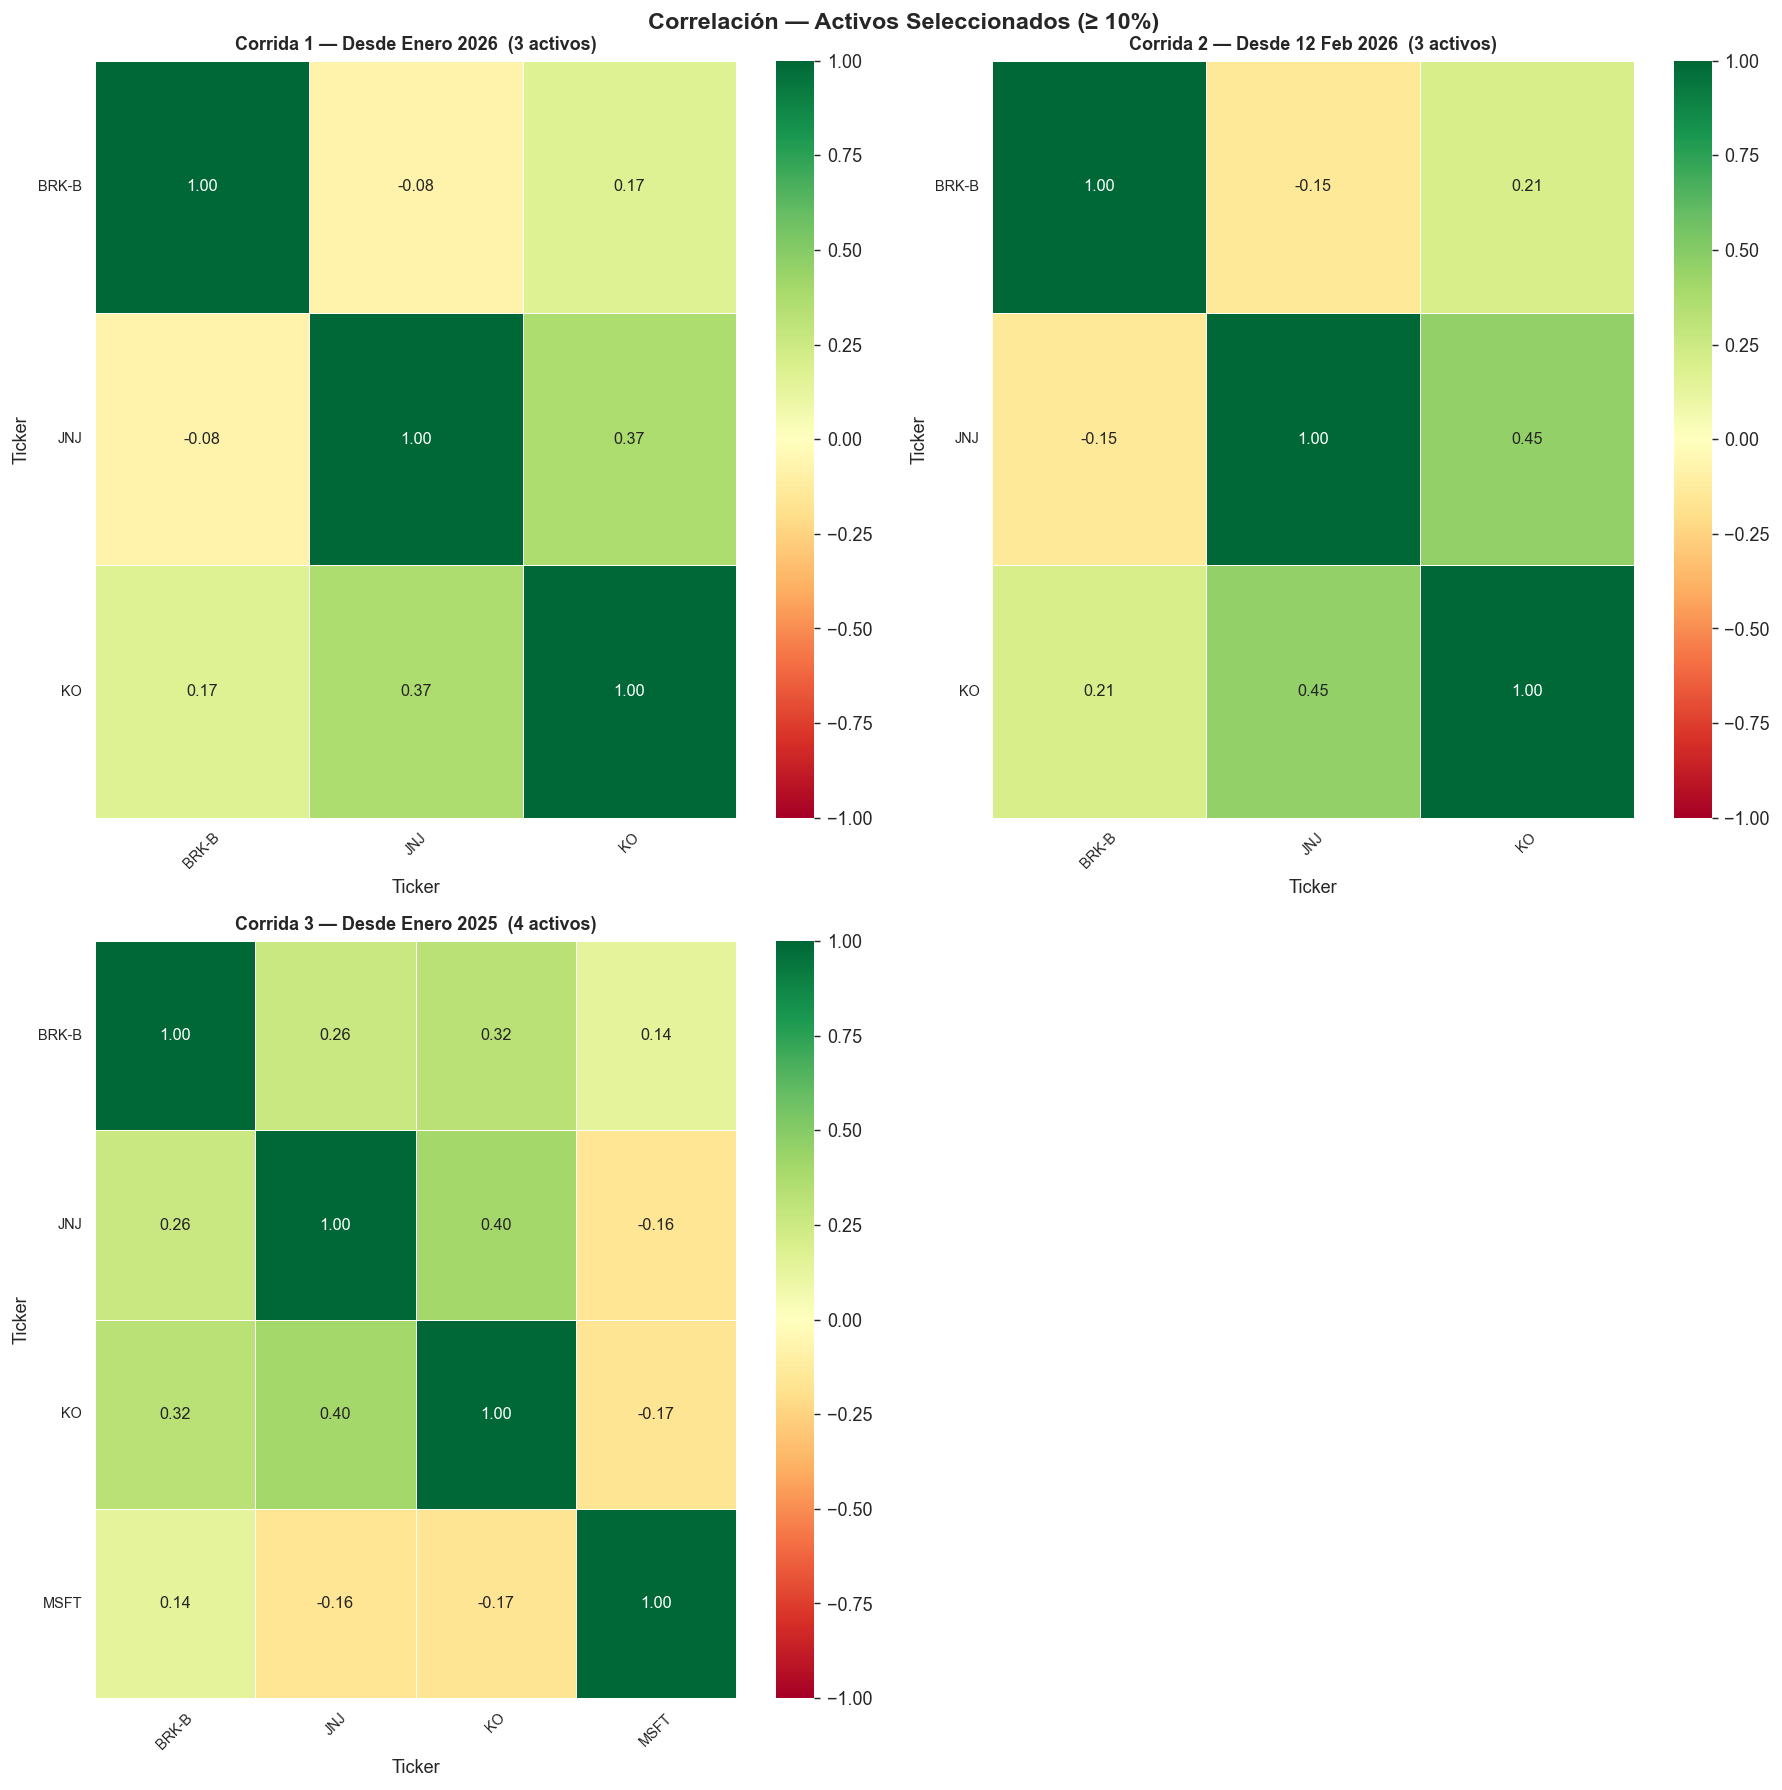

In [ ]:
# ============================================================
# B6. CORRELACIÓN — ACTIVOS SELECCIONADOS (portafolio filtrado)
# ============================================================
ncols     = 2
nrows     = (len(nombres_f) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7 * nrows))
if nrows == 1 and ncols == 1: axes = np.array([[axes]])
elif nrows == 1: axes = axes.reshape(1, -1)
axes_flat = axes.flatten()
fig.suptitle('Correlación — Activos Seleccionados (≥ 10%)', fontsize=13, fontweight='bold')

for i, (nombre, res) in enumerate(resultados_filtrados.items()):
    ax   = axes_flat[i]
    sel  = res['pesos'][res['pesos'] > 0.001].index.tolist()
    corr = res['retornos'][sel].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1,
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 9})
    ax.set_title(f'{nombre}  ({len(sel)} activos)', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

for j in range(len(nombres_f), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()


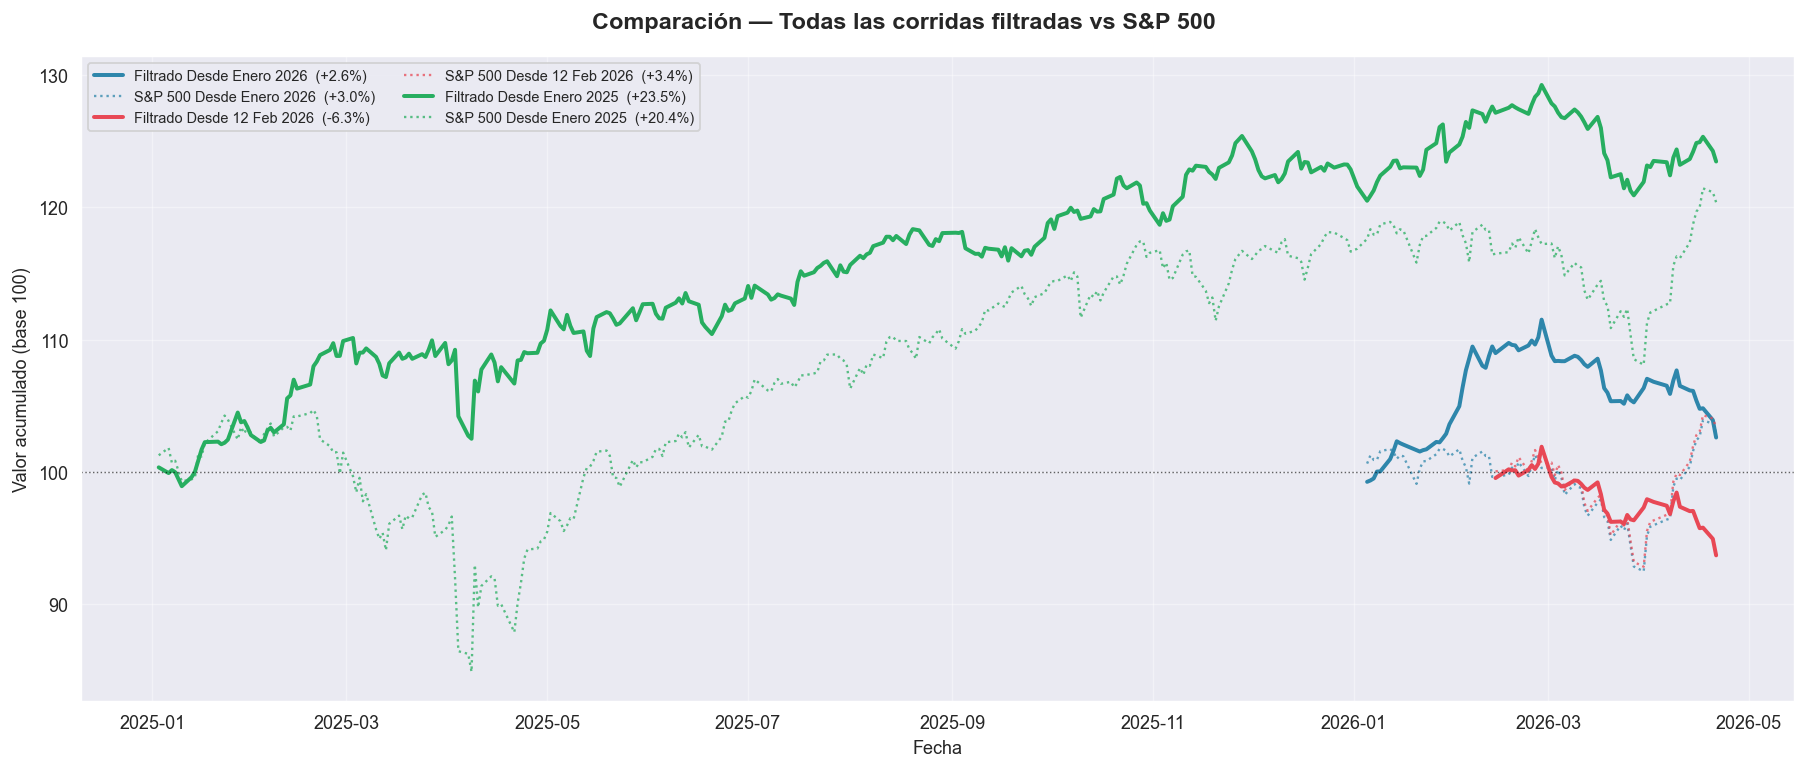


✅ Análisis completado exitosamente.


In [ ]:
# ============================================================
# B7. COMPARACIÓN — TODAS LAS CORRIDAS FILTRADAS + S&P 500
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Comparación — Todas las corridas filtradas vs S&P 500', fontsize=13, fontweight='bold')

for (nombre, res), color in zip(resultados_filtrados.items(), colores_f):
    cfg      = PERIODOS[nombre]
    pesos    = res['pesos'].values
    ret_log  = res['retornos'][res['pesos'].index]
    port_val = 100 * np.exp((ret_log @ pesos).cumsum())
    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre

    ax.plot(port_val.index, port_val, color=color, linewidth=2.2,
            label=f'Filtrado {etiqueta}  ({port_val.iloc[-1]-100:+.1f}%)')

    # S&P 500 sincronizado — empieza en la misma fecha que esta corrida
    sp500_val = get_sp500(cfg['start'], cfg['end'])
    ax.plot(sp500_val.index, sp500_val, color=color, linewidth=1.3,
            linestyle=':', alpha=0.75,
            label=f'S&P 500 {etiqueta}  ({sp500_val.iloc[-1]-100:+.1f}%)')

ax.axhline(100, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_ylabel('Valor acumulado (base 100)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('\n✅ Análisis completado exitosamente.')
